# Lecture 3: PyMC and Sampling
## Contents
- [3.1 Graphical models](#section-31)
- [3.2 Probabilistic programming languages](#section-32)
- [3.3 Sampling](#section-33)
- [3.4 Plotting the posterior distribution](#section-34)
- [3.5 Estimation](#section-35)
- [3.6 HDI](#section-36)
- [3.7 Frequentist vs Bayesian philosophies](#section-37)
- [3.8 Frequentist estimation](#section-38)
- [3.9 Maximum likelihood](#section-39)
- [3.10 Confidence intervals](#section-310)
- [3.11 Next time: MCMC](#section-311)

## Setup

### Data access policy
This notebook is designed to run cleanly in Colab without requiring students to clone the full course repository. Most of Lecture 3 uses synthetic examples, and the frequentist-estimation section downloads one course data file directly from the course GitHub source.

Colab package versions change over time. The setup cell below checks the Colab runtime and upgrades the Bayesian-analysis packages when they are older than the versions used for this notebook.

In [1]:
import importlib.metadata
import subprocess
import sys

IS_COLAB = "google.colab" in sys.modules
MIN_PACKAGE_VERSIONS = {
    "pymc": "5.25.1",
    "arviz": "0.23.4",
    "arviz-stats": "0.8.0",
    "preliz": "0.24.0",
}

def ensure_colab_packages(package_min_versions):
    if not IS_COLAB:
        return

    from importlib.metadata import PackageNotFoundError, version
    from packaging.version import Version

    packages_to_install = []
    for package_name, min_version in package_min_versions.items():
        try:
            current_version = version(package_name)
        except PackageNotFoundError:
            current_version = None
        if current_version is None or Version(current_version) < Version(min_version):
            packages_to_install.append(f"{package_name}>={min_version}")

    if packages_to_install:
        print("Upgrading Colab packages:", ", ".join(packages_to_install))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", *packages_to_install])
        print("Upgrade complete. If imports fail, restart the runtime and run all cells again.")
    else:
        print("Colab runtime already satisfies the notebook package requirements.")

ensure_colab_packages(MIN_PACKAGE_VERSIONS)

### Required data files

In [2]:
REQUIRED_DATA_FILES = {
    "chemical_shifts": "https://github.com/aloctavodia/BAP3/raw/refs/heads/main/code/data/chemical_shifts_theo_exp.csv",
}

### Resolve required data files

In [3]:
DATA_FILE_PATHS = REQUIRED_DATA_FILES
DATA_FILE_PATHS

{'chemical_shifts': 'https://github.com/aloctavodia/BAP3/raw/refs/heads/main/code/data/chemical_shifts_theo_exp.csv'}

### Do imports and settings

In [4]:
import arviz as az
import arviz_stats as azs
from graphviz import Digraph
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
import scipy.stats as stats
import seaborn as sns

In [5]:
rng = np.random.default_rng(123)
az.style.use("arviz-whitegrid")
sns.set_context("notebook")
plt.rcParams["figure.dpi"] = 150

<a id="section-31"></a>
## 3.1 Graphical models
### Representing models using graphs

### Basic styles
The slides emphasize a simple reading order for graphical models: data at the bottom, likelihood in the middle, and prior information at the top. We will show the same beta-Bernoulli model in two common styles: a simple DAG and plate notation.

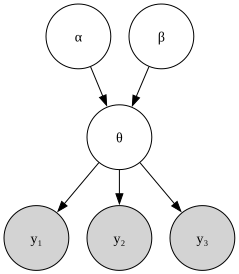

In [6]:
dag = Digraph(format="svg")
dag.attr(rankdir="TB", splines="true")
dag.attr("node", shape="circle", fixedsize="true", width="0.9")

# Hyperparameters
dag.node("alpha", "α")
dag.node("beta", "β")

# Latent parameter
dag.node("theta", "θ")

# Observations
dag.node("y1", "y₁", style="filled", fillcolor="lightgray")
dag.node("y2", "y₂", style="filled", fillcolor="lightgray")
dag.node("y3", "y₃", style="filled", fillcolor="lightgray")

# Edges
dag.edge("alpha", "theta")
dag.edge("beta", "theta")
dag.edge("theta", "y1")
dag.edge("theta", "y2")
dag.edge("theta", "y3")

dag

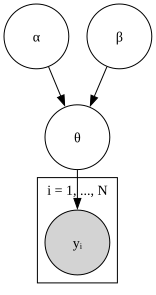

In [7]:
plate = Digraph(format="svg")
plate.attr(rankdir="TB", splines="true")
plate.attr("node", shape="circle", fixedsize="true", width="0.9")

# Hyperparameters
plate.node("alpha", "α")
plate.node("beta", "β") 
    
# Latent parameter
plate.node("theta", "θ")

# Plate for repeated observations
with plate.subgraph(name="cluster_obs") as c:
    c.attr(label="i = 1, ..., N", color="black")
    c.node("yi", "yᵢ", style="filled", fillcolor="lightgray")

# Edges
plate.edge("alpha", "theta")
plate.edge("beta", "theta")
plate.edge("theta", "yi")

plate

### From equations to graphical model to PyMC
For the coin-toss example we can write the model as $\theta \sim \mathrm{Beta}(\alpha, \beta)$ and $y_i \sim \mathrm{Bernoulli}(\theta)$. The same probabilistic idea can be written as equations, as a graphical model, or directly in PyMC.

In [8]:
np.random.seed(123)
sample_size = 30
theta_real = 0.8  # simulated data-generating value used throughout the notebook
data = pz.Binomial(n=1, p=theta_real).rvs(sample_size, random_state=123)
data

array([1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1])

In [9]:
with pm.Model() as our_first_model:
    theta = pm.Beta('theta', alpha=1., beta=1.)
    y = pm.Bernoulli('y', p=theta, observed=data)

<a id="section-32"></a>
## 3.2 Probabilistic programming languages
### Why PPLs matter

- 1930s-1950s: Bayesian inference was mostly limited to analytic calculations.
- 1950s-1980s: those analytic approaches were too restrictive for many realistic models.
- Early 1990s: MCMC made approximate posterior computation practical.
- Mid 1990s-2000s: early PPLs such as BUGS automated much of that computation.
- Today: PyMC lets us build models and sample from them directly in Python, with ArviZ handling posterior summaries and plots.

### PyMC: a PPL for Python
```python
with pm.Model() as our_first_model:
    theta = pm.Beta("theta", alpha=1.0, beta=1.0)
    y = pm.Bernoulli("y", p=theta, observed=data)
```

This is the same model we just wrote as equations and as a graphical model, now expressed in a probabilistic programming language.

### A PPL has at least two parts
- Model building: specify the prior, likelihood, and dependencies.
- Sampling: generate draws from the posterior once the model is defined.

In PyMC those two parts appear naturally as `pm.Model(...)` followed by `pm.sample(...)`.

### The PyMC graphical visualizer

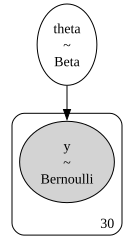

In [10]:
pm.model_to_graphviz(our_first_model)

<a id="section-33"></a>
## 3.3 Sampling
### Using sampling to approximate the posterior distribution

- We sample when exact analytic solutions are unavailable or inconvenient.
- Analytic Bayes often needs a conjugate prior that matches the likelihood.
- Grid solutions are useful for one parameter, but they become impractical once the number of parameters grows.
- Samples let us characterize a distribution directly, and larger samples give more stable summaries.

D:\Repositories\StatisticalComputationAndAnalysis\.pixi\envs\default\Lib\site-packages\pytensor\link\numba\dispatch\basic.py:211: UserWarning: Numba will use object mode to run XlogY0's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


C:\Users\User\AppData\Local\Temp\ipykernel_31560\4156904083.py:29: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


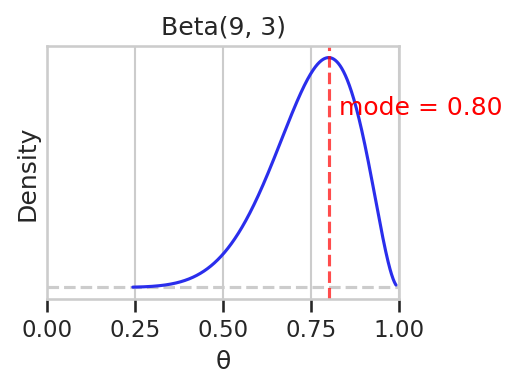

In [11]:
alpha = 9
beta = 3

# Create a figure and axis
fig, ax = plt.subplots(figsize=(9/2.54, 7/2.54))

# Generate the Beta distribution plot
x = np.linspace(0, 1, 1000)
dist = pz.Beta(alpha=alpha, beta=beta)
dist.plot_pdf(ax=ax, legend=None)

# Calculate the actual mode of the Beta distribution
actual_mode = (alpha - 1) / (alpha + beta - 2)

# Add the mode to the plot
ax.axvline(actual_mode, linestyle='--', color='red', alpha=0.7)
ax.text(actual_mode + 0.03, 2.6, f"mode = {actual_mode:.2f}", 
    color='red', fontsize=12, va='center')

# Add labels and title
ax.set_xlabel('θ')
ax.set_ylabel('Density')
ax.set_title(f'Beta({alpha:.0f}, {beta:.0f})')

# Set limits and adjust layout
ax.set_xlim(0, 1.0)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])

plt.tight_layout()

C:\Users\User\AppData\Local\Temp\ipykernel_31560\3669010492.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


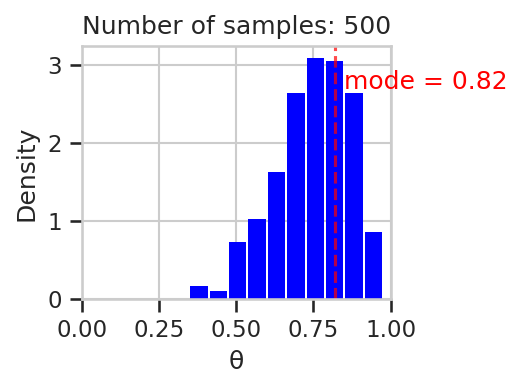

C:\Users\User\AppData\Local\Temp\ipykernel_31560\3669010492.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


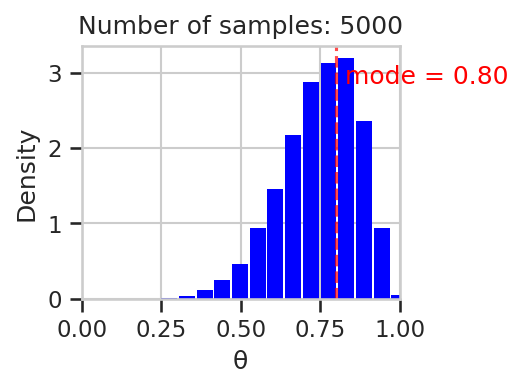

C:\Users\User\AppData\Local\Temp\ipykernel_31560\3669010492.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


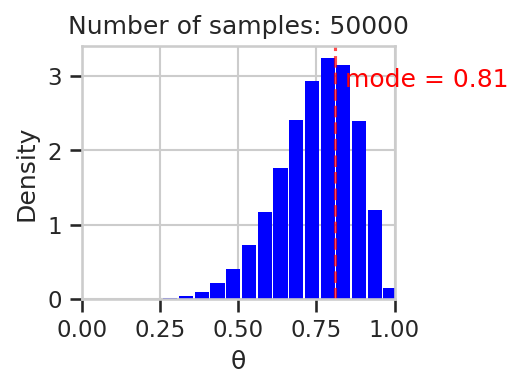

In [12]:
sample_sizes = [500, 5000, 50000]

for size in sample_sizes:
    # Sample from the Beta distribution
    samples = dist.rvs(size=size, random_state=123)

    # Create a new figure and axis
    fig, ax = plt.subplots(figsize=(9/2.54, 7/2.54))

    # Plot histogram using ArviZ (with density normalization)
    az.plot_dist(samples, ax=ax, kind='hist', color='blue')

    # Estimate KDE to find the sample mode
    kde_x, kde_y = az.kde(samples)
    sample_mode = kde_x[np.argmax(kde_y)]

    # Add mode line and text
    ax.axvline(sample_mode, linestyle='--', color='red', alpha=0.7)
    ax.text(sample_mode + 0.03, max(kde_y)*0.9, f"mode = {sample_mode:.2f}", 
            color='red', fontsize=12, va='center')

    # Labels and limits
    ax.set_xlabel('θ')
    ax.set_ylabel('Density')
    ax.set_title(f'Number of samples: {size}')
    ax.set_xlim(0, 1.0)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])

    # Layout
    plt.tight_layout()
    plt.show()



### Sampling and PPLs

In [13]:
idata = pm.sample(1000, model=our_first_model, random_seed=4591)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [theta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 91 seconds.


In [14]:
idata

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

### What happens when we call `pm.sample()`?

- Pick a sampling algorithm.
- Initialize the parameters.
- Run multiple chains so we can inspect convergence and variability.
- Store the resulting posterior draws in an ArviZ `InferenceData` object.
- In `idata.posterior`, the key dimensions are `chain` and `draw`.
- In this lecture we use `sample` for observed data and `draw` for posterior values.

C:\Users\User\AppData\Local\Temp\ipykernel_31560\522415337.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


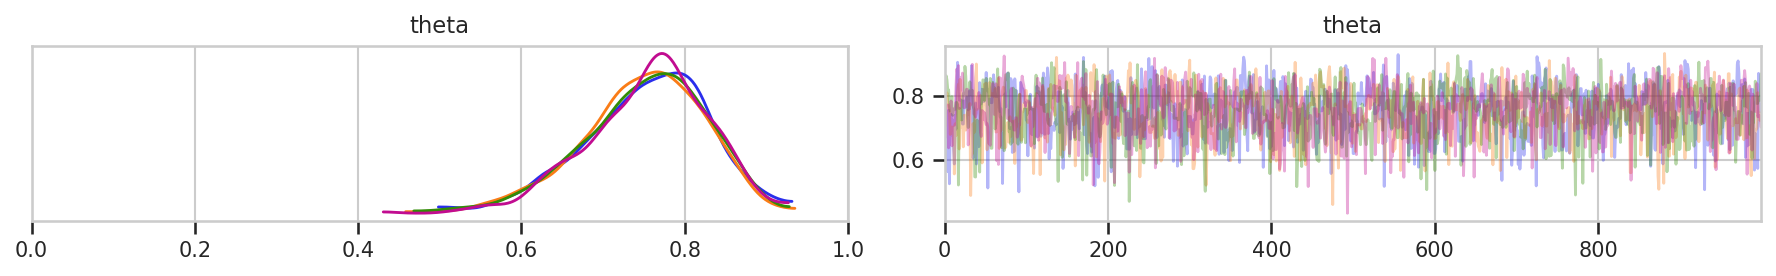

In [15]:
trace_axes = az.plot_trace(idata, chain_prop="color")
trace_axes = np.atleast_2d(trace_axes)

for ax in trace_axes[:, 0].ravel():
    ax.set_xlim(0, 1)

plt.tight_layout()

<a id="section-34"></a>
## 3.4 Plotting the posterior distribution
### ArviZ tools for visualizing the posterior

ArviZ: analyzing Bayesian data. The lecture uses ArviZ for posterior summaries and visualizations.

Documentation: <https://python.arviz.org/en/stable/>

In [16]:
az.summary(idata, kind="stats").round(2)

,mean,sd,hdi_3%,hdi_97%
theta,0.75,0.08,0.6,0.88


C:\Users\User\AppData\Local\Temp\ipykernel_31560\2144538983.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


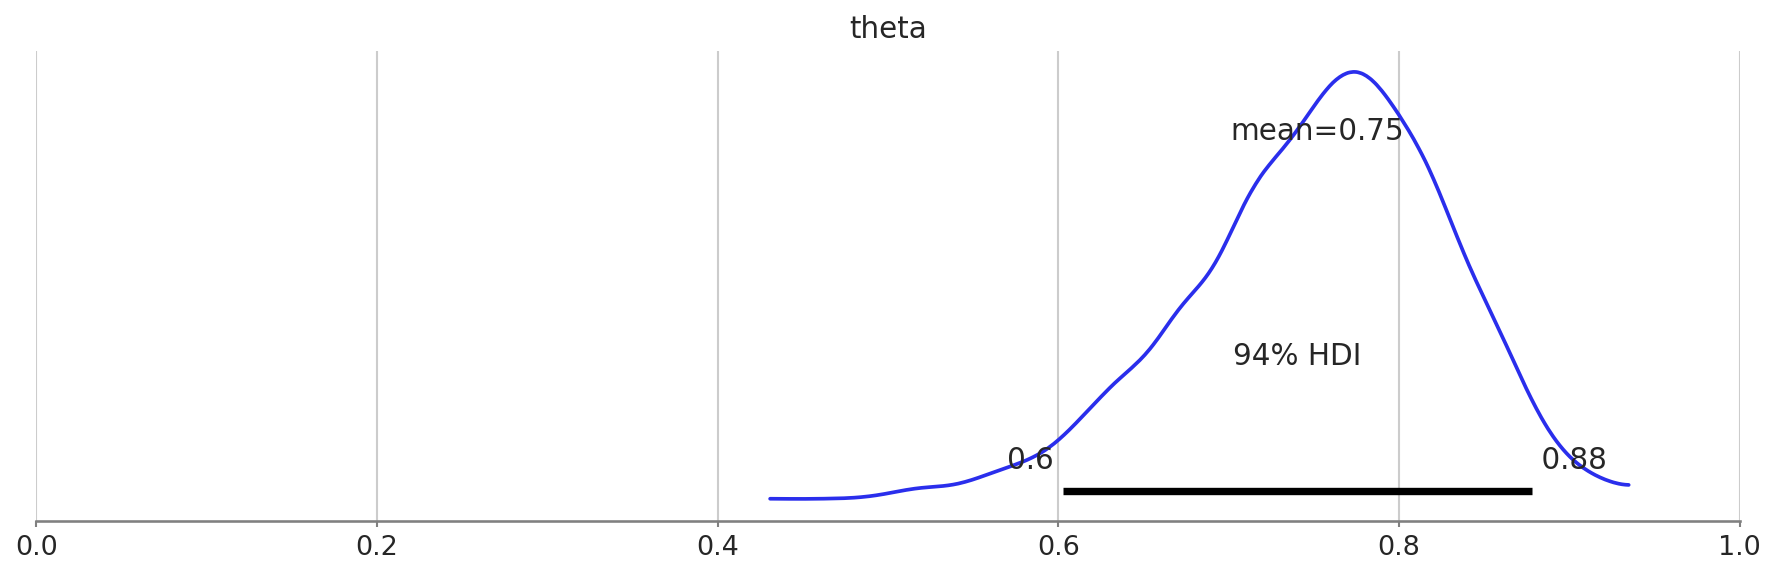

In [17]:
posterior_axes = az.plot_posterior(idata, figsize=(12, 4))

for ax in np.ravel(np.atleast_1d(posterior_axes)):
    ax.set_xlim(0, 1)

plt.tight_layout()

<a id="section-35"></a>
## 3.5 Estimation
### Mean, median, and mode as posterior summaries

- For a posterior distribution we often summarize the parameter with a point estimate.
- The slides compare the posterior mean, posterior median, and posterior mode.
- To understand those estimators, we simulate many datasets from the same true $p$ and look at the distribution of the resulting estimates.
- This lets us talk about bias and variance, not just one posterior from one dataset.

C:\Users\User\AppData\Local\Temp\ipykernel_31560\3243335656.py:58: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0.35)


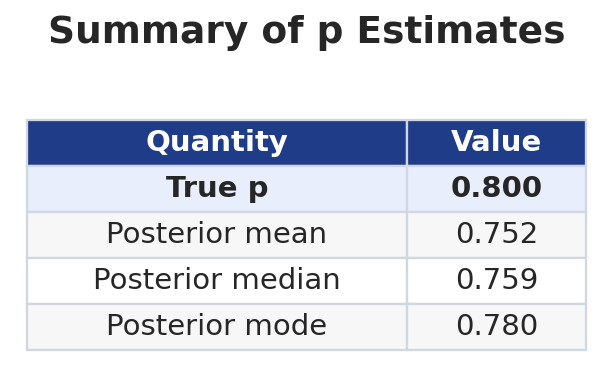

In [18]:
posterior_theta = az.extract(idata, var_names=["theta"]).to_numpy().ravel()
posterior_mean = posterior_theta.mean()
posterior_median = np.median(posterior_theta)
posterior_mode = float(np.asarray(azs.mode(posterior_theta)).squeeze())
theta_summaries = pd.Series({
    "true p": theta_real,
    "mean": posterior_mean,
    "median": posterior_median,
    "mode": posterior_mode,
})

theta_summary_table = pd.DataFrame({
    "Quantity": ["True p", "Posterior mean", "Posterior median", "Posterior mode"],
    "Value": [
        theta_summaries["true p"],
        theta_summaries["mean"],
        theta_summaries["median"],
        theta_summaries["mode"],
    ],
})
theta_summary_table["Value"] = theta_summary_table["Value"].map(lambda value: f"{value:.3f}")

fig, ax = plt.subplots(figsize=(4, 2.35))
fig.patch.set_facecolor("white")
ax.axis("off")

summary_table = ax.table(
    cellText=theta_summary_table.values,
    colLabels=theta_summary_table.columns,
    colLoc="center",
    cellLoc="center",
    colWidths=[0.68, 0.32],
    bbox=[0.02, 0.0, 0.96, 0.78],
)
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(14)
summary_table.scale(1.0, 1.35)

header_color = "#1f3c88"
highlight_color = "#e8eefc"
stripe_color = "#f7f7f7"
edge_color = "#d0d7e2"

for (row, col), table_cell in summary_table.get_celld().items():
    table_cell.PAD = 0.02
    table_cell.set_edgecolor(edge_color)
    table_cell.set_linewidth(1.1)
    if row == 0:
        table_cell.set_facecolor(header_color)
        table_cell.set_text_props(color="white", weight="bold", fontsize=14)
    elif row == 1:
        table_cell.set_facecolor(highlight_color)
        table_cell.set_text_props(weight="bold")
    elif row % 2 == 0:
        table_cell.set_facecolor(stripe_color)

ax.set_title("Summary of p Estimates", fontsize=18, fontweight="bold", pad=6)
plt.tight_layout(pad=0.35)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_31560\2562025760.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


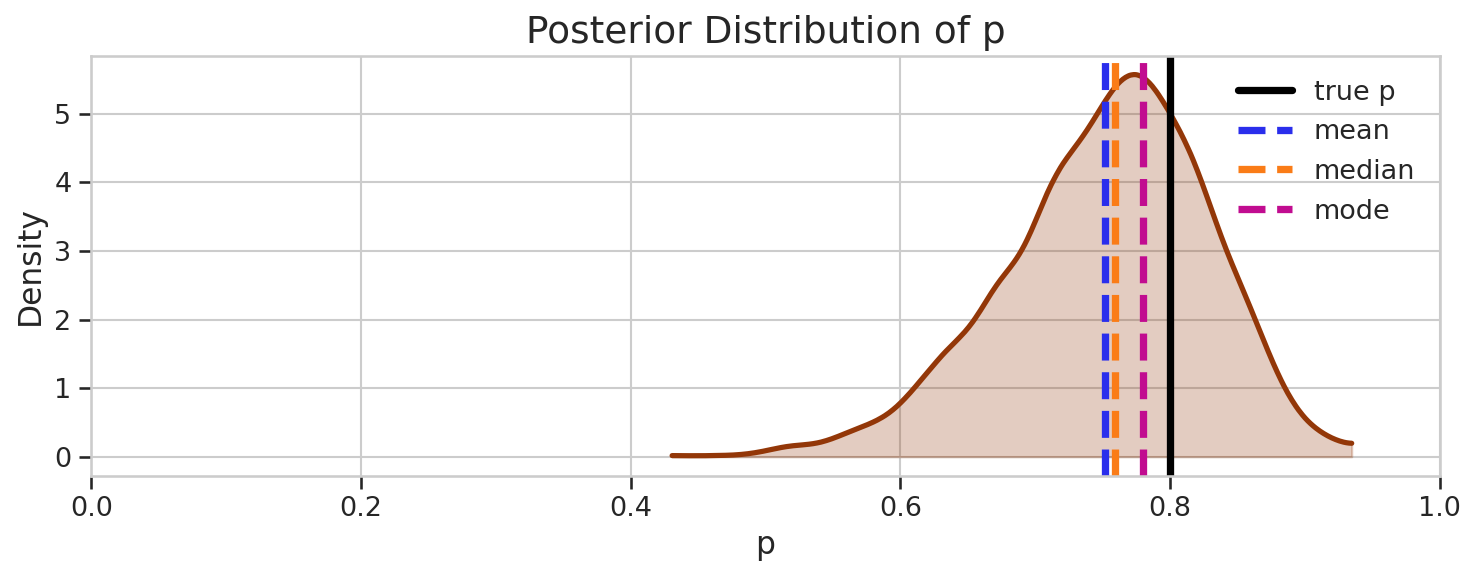

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
density_x, density_y = az.kde(posterior_theta)
ax.plot(density_x, density_y, color="C4", linewidth=2.5)
ax.fill_between(density_x, 0, density_y, color="C4", alpha=0.25)

line_specs = [
    ("true p", "black", "-"),
    ("mean", "C0", "--"),
    ("median", "C1", "--"),
    ("mode", "C3", "--"),
]
for label, color, linestyle in line_specs:
    value = theta_summaries[label]
    ax.axvline(value, color=color, linestyle=linestyle, linewidth=3.5, label=label)

ax.set_xlim([0, 1])
ax.set_title("Posterior Distribution of p", fontsize=18)
ax.set_xlabel("p", fontsize=15)
ax.set_ylabel("Density", fontsize=15)
ax.tick_params(axis="both", labelsize=13)
ax.legend(fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
num_simulated_datasets = 1000
posterior_draws_per_dataset = posterior_theta.size
dataset_size = len(data)

simulated_head_counts = pz.Binomial(n=dataset_size, p=theta_real).rvs(
    num_simulated_datasets,
    random_state=123,
)
posterior_alpha_samples = 1 + simulated_head_counts
posterior_beta_samples = 1 + dataset_size - simulated_head_counts

posterior_theta_samples = np.empty((num_simulated_datasets, posterior_draws_per_dataset))
for i, (alpha_i, beta_i) in enumerate(zip(posterior_alpha_samples, posterior_beta_samples)):
    posterior_dist = pz.Beta(alpha=alpha_i, beta=beta_i)
    posterior_theta_samples[i] = posterior_dist.rvs(
        posterior_draws_per_dataset,
        random_state=int(rng.integers(0, 2**32 - 1)),
    )

posterior_means = posterior_theta_samples.mean(axis=1)
posterior_medians = np.median(posterior_theta_samples, axis=1)
posterior_modes = np.array([
    float(np.asarray(azs.mode(samples)).squeeze())
    for samples in posterior_theta_samples
])

summary_df = pd.DataFrame({
    "heads": simulated_head_counts,
    "posterior_mean": posterior_means,
    "posterior_median": posterior_medians,
    "posterior_mode": posterior_modes,
})
summary_df.head()

,heads,posterior_mean,posterior_median,posterior_mode
0,23,0.750937,0.754912,0.75
1,27,0.875340,0.884177,0.91
2,26,0.842245,0.849318,0.88
3,26,0.843305,0.851107,0.86
4,26,0.842015,0.848485,0.88


Across repeated datasets from the same true parameter, the posterior itself changes. That gives us repeated posterior means, medians, and modes whose distributions we can compare directly.

C:\Users\User\AppData\Local\Temp\ipykernel_31560\3645286295.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


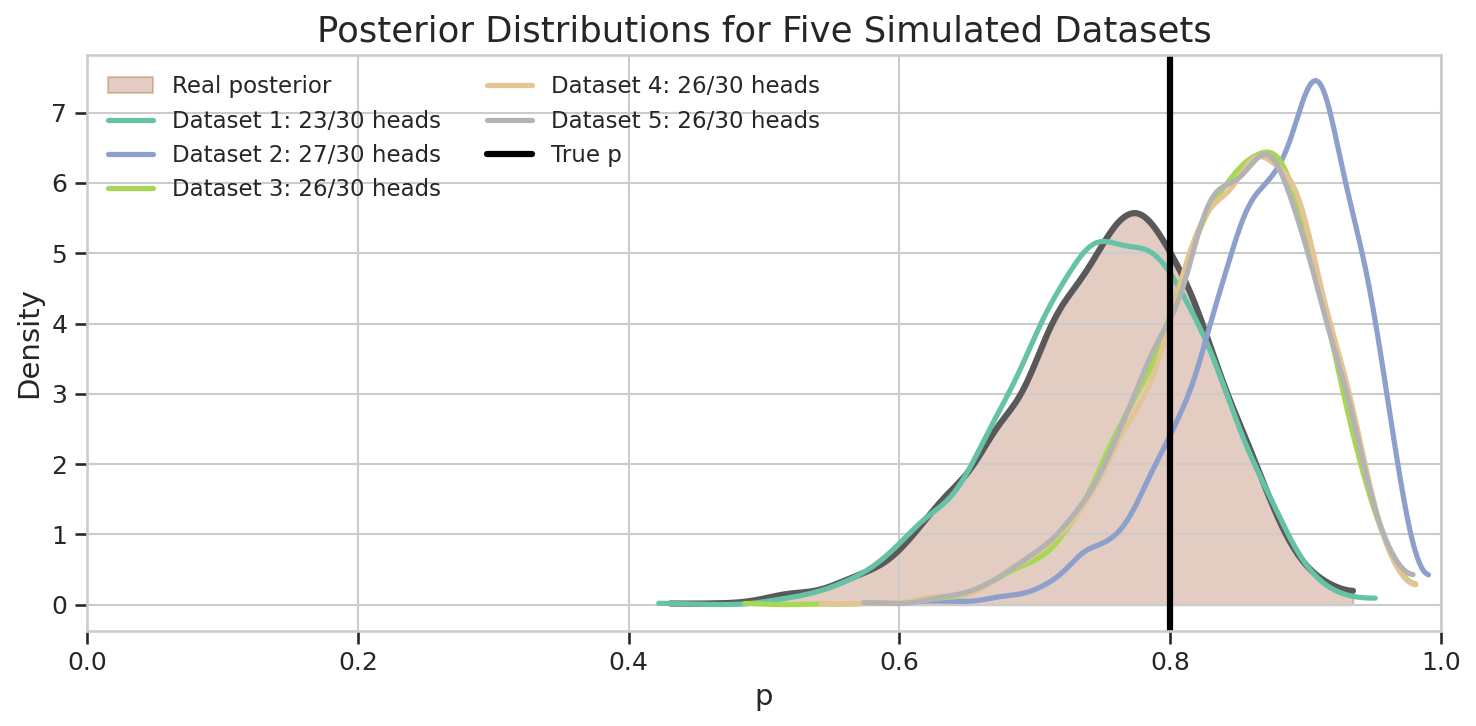

In [21]:
posterior_colors = plt.cm.Set2(np.linspace(0, 1, 5))

fig, ax = plt.subplots(figsize=(10, 5))
# "Real" posterior from the original simulated dataset
real_kde_x, real_kde_y = az.kde(posterior_theta)
ax.plot(real_kde_x, real_kde_y, color="0.35", linewidth=3)
ax.fill_between(real_kde_x, 0, real_kde_y, color="C4", alpha=0.25, zorder=0, label="Real posterior")

# Posteriors for five newly simulated datasets
for i, color in enumerate(posterior_colors):
    kde_x, kde_y = az.kde(posterior_theta_samples[i])
    ax.plot(
        kde_x,
        kde_y,
        color=color,
        linewidth=2.5,
        label=f"Dataset {i + 1}: {simulated_head_counts[i]}/{dataset_size} heads",
    )

ax.set_xlim([0, 1])
ax.axvline(theta_real, color="black", linewidth=3, label="True p")
ax.set_title("Posterior Distributions for Five Simulated Datasets", fontsize=17)
ax.set_xlabel("p", fontsize=14)
ax.set_ylabel("Density", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=11, ncols=2)
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_31560\2216912459.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


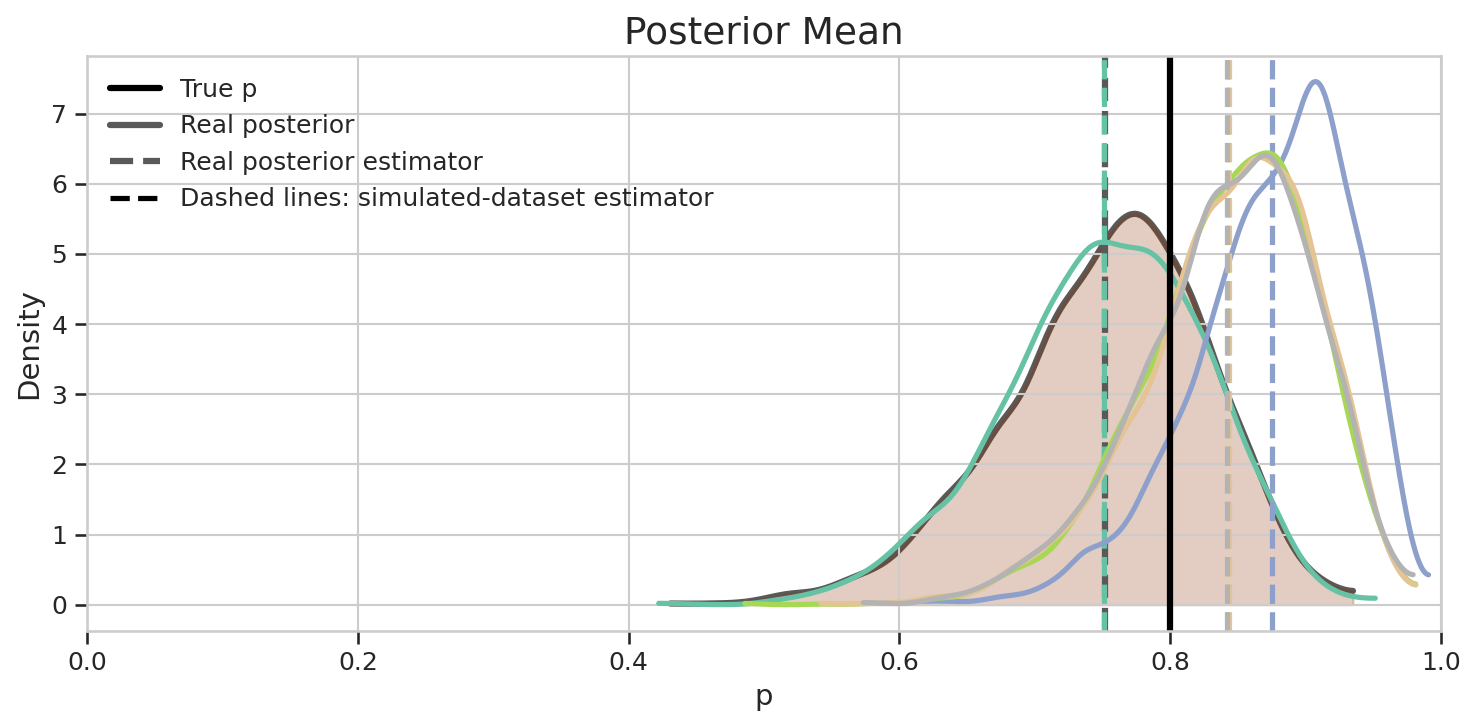

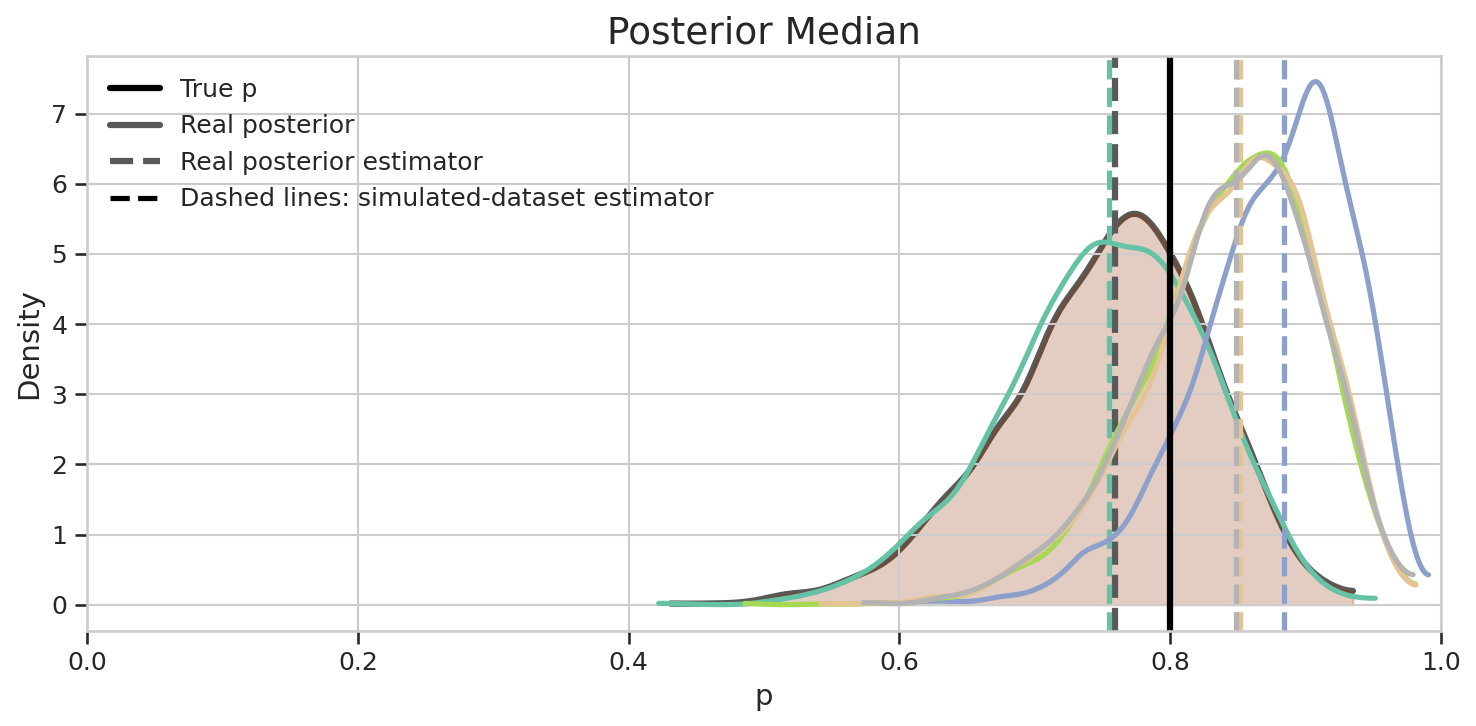

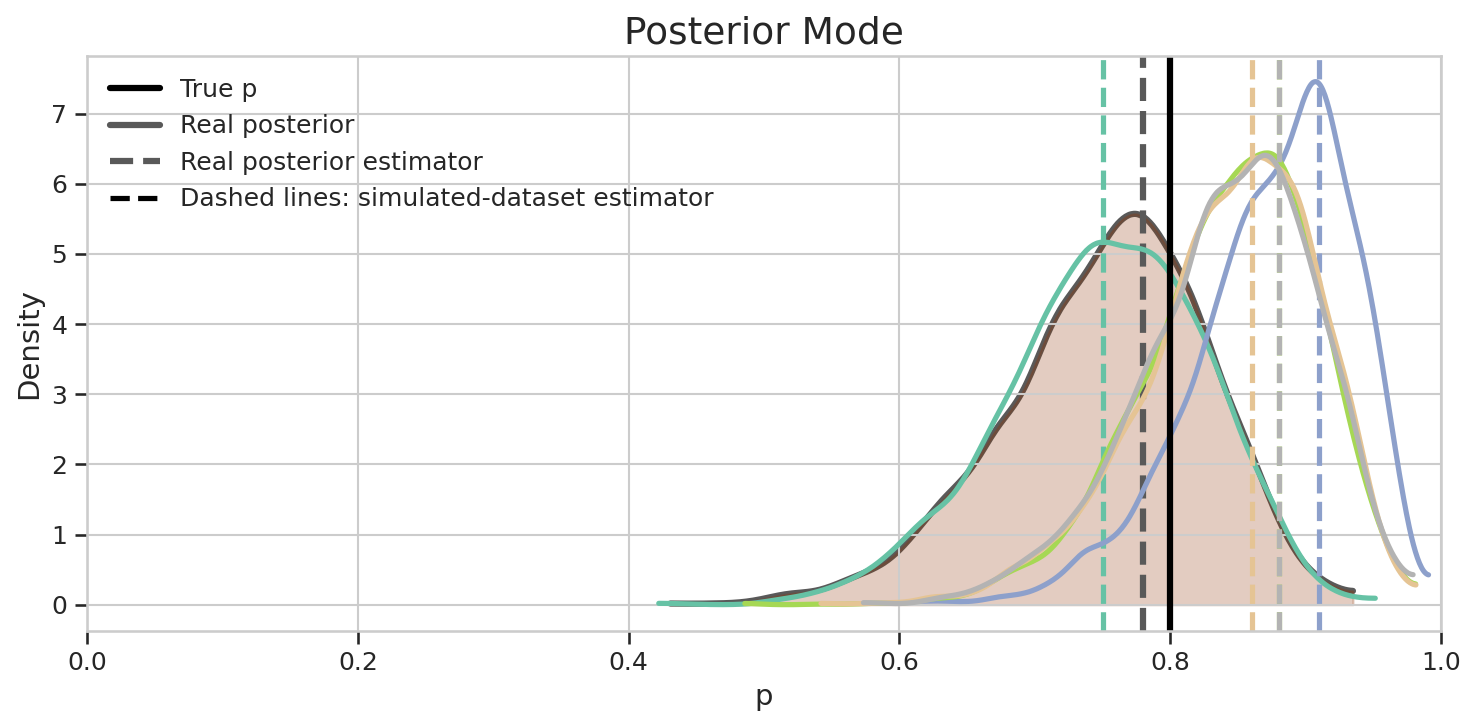

In [22]:
from matplotlib.lines import Line2D

estimator_specs = [
    ("Posterior Mean", posterior_means[:5], posterior_mean),
    ("Posterior Median", posterior_medians[:5], posterior_median),
    ("Posterior Mode", posterior_modes[:5], posterior_mode),
]

for estimator_title, estimator_values, real_estimator_value in estimator_specs:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(real_kde_x, real_kde_y, color="0.35", linewidth=3, zorder=0)
    ax.fill_between(real_kde_x, 0, real_kde_y, color="C4", alpha=0.25, zorder=0)
    ax.axvline(real_estimator_value, color="0.35", linestyle="--", linewidth=3)
    for i, color in enumerate(posterior_colors):
        kde_x, kde_y = az.kde(posterior_theta_samples[i])
        ax.plot(kde_x, kde_y, color=color, linewidth=2.5)
        ax.axvline(estimator_values[i], color=color, linestyle="--", linewidth=2.5)

    ax.set_xlim([0, 1])

    ax.axvline(theta_real, color="black", linewidth=3)
    legend_handles = [
        Line2D([0], [0], color="black", linewidth=3, linestyle="-", label="True p"),
        Line2D([0], [0], color="0.35", linewidth=3, linestyle="-", label="Real posterior"),
        Line2D([0], [0], color="0.35", linewidth=3, linestyle="--", label="Real posterior estimator"),
        Line2D([0], [0], color="black", linewidth=2.5, linestyle="--", label="Dashed lines: simulated-dataset estimator"),
    ]
    ax.legend(handles=legend_handles, fontsize=12)
    ax.set_title(estimator_title, fontsize=18)
    ax.set_xlabel("p", fontsize=14)
    ax.set_ylabel("Density", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    plt.tight_layout()
    plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_31560\2764526015.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


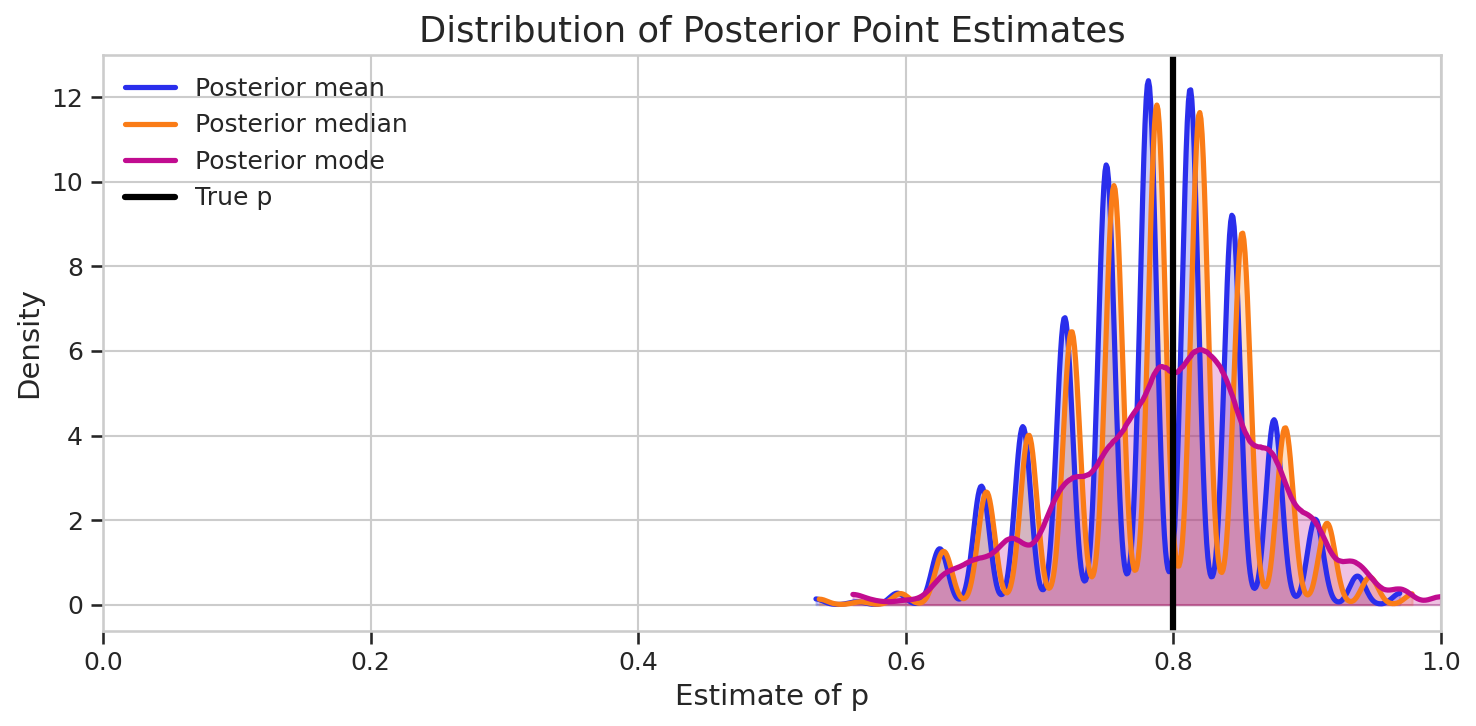

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
summary_kdes = [
    ("Posterior mean", posterior_means, "C0"),
    ("Posterior median", posterior_medians, "C1"),
    ("Posterior mode", posterior_modes, "C3"),
]

for label, values, color in summary_kdes:
    kde_x, kde_y = az.kde(values)
    ax.plot(kde_x, kde_y, color=color, linewidth=2.5, label=label)
    ax.fill_between(kde_x, 0, kde_y, color=color, alpha=0.25)

ax.set_xlim([0, 1])
ax.axvline(theta_real, color="black", linewidth=3, label="True p")
ax.set_title("Distribution of Posterior Point Estimates", fontsize=17)
ax.set_xlabel("Estimate of p", fontsize=14)
ax.set_ylabel("Density", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_31560\3594352999.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


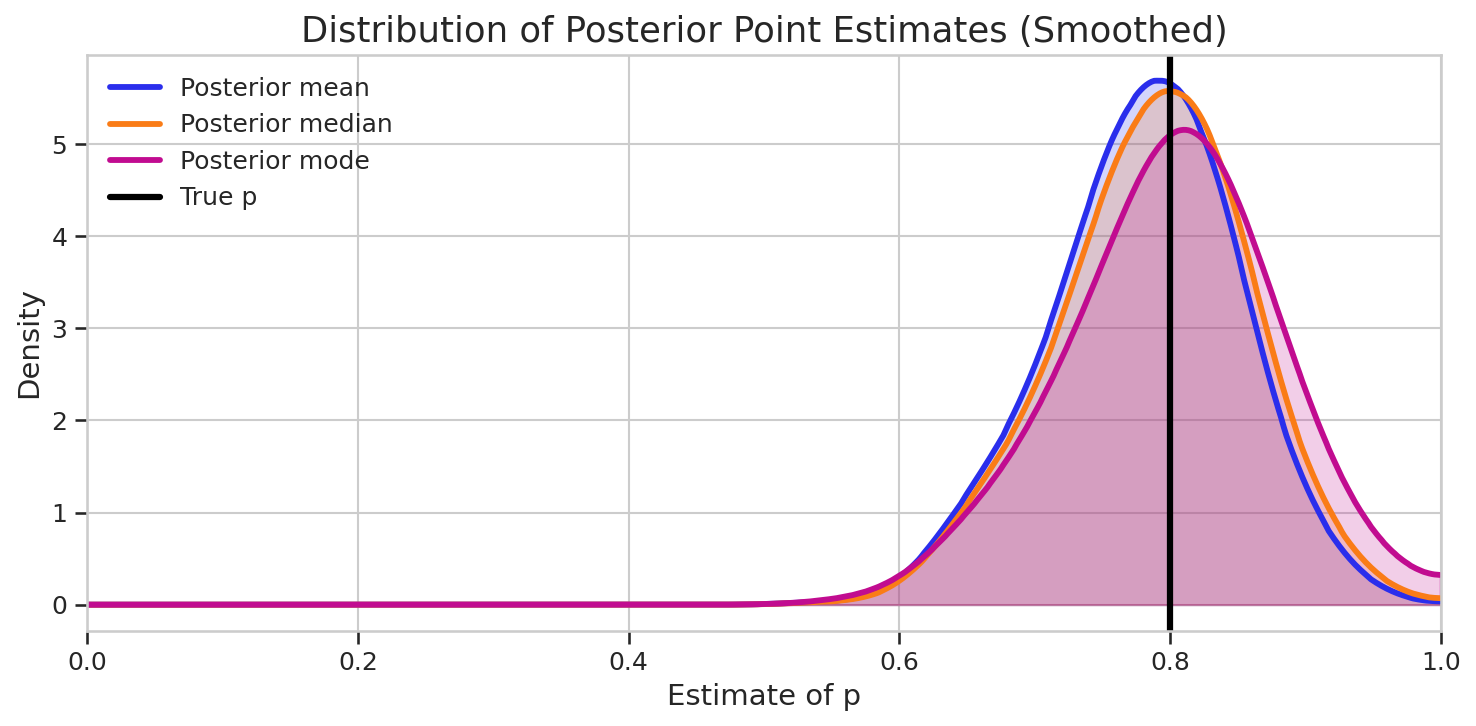

In [24]:
smoothed_bw_factor = 4.0

fig, ax = plt.subplots(figsize=(10, 5))
for label, values, color in summary_kdes:
    kde_x, kde_y = az.kde(values, bw_fct=smoothed_bw_factor, custom_lims=(0, 1))
    ax.plot(kde_x, kde_y, color=color, linewidth=2.8, label=label)
    ax.fill_between(kde_x, 0, kde_y, color=color, alpha=0.2)

ax.set_xlim([0, 1])
ax.axvline(theta_real, color="black", linewidth=3, label="True p")
ax.set_title("Distribution of Posterior Point Estimates (Smoothed)", fontsize=17)
ax.set_xlabel("Estimate of p", fontsize=14)
ax.set_ylabel("Density", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_31560\3922483413.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


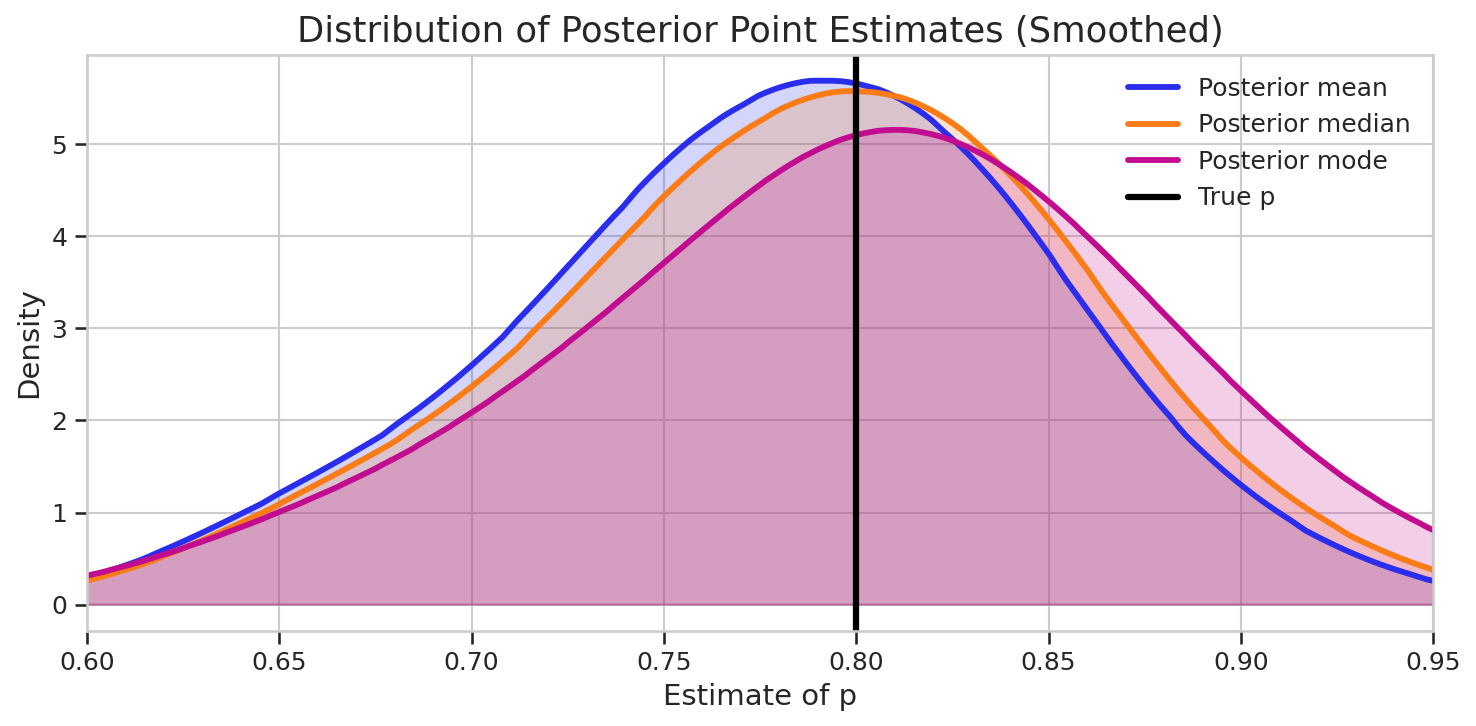

In [25]:
smoothed_bw_factor = 4.0

fig, ax = plt.subplots(figsize=(10, 5))
for label, values, color in summary_kdes:
    kde_x, kde_y = az.kde(values, bw_fct=smoothed_bw_factor, custom_lims=(0, 1))
    ax.plot(kde_x, kde_y, color=color, linewidth=2.8, label=label)
    ax.fill_between(kde_x, 0, kde_y, color=color, alpha=0.2)

ax.set_xlim([0.6, 0.95])
ax.axvline(theta_real, color="black", linewidth=3, label="True p")
ax.set_title("Distribution of Posterior Point Estimates (Smoothed)", fontsize=17)
ax.set_xlabel("Estimate of p", fontsize=14)
ax.set_ylabel("Density", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

The slides emphasize the bias-variance tradeoff: an estimator that is more accurate can be less precise, and vice versa. In practice the posterior mean is often preferred because it uses the whole posterior, while the posterior mode can be attractive when the posterior is strongly asymmetric.

C:\Users\User\AppData\Local\Temp\ipykernel_31560\1352497817.py:57: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0.25)


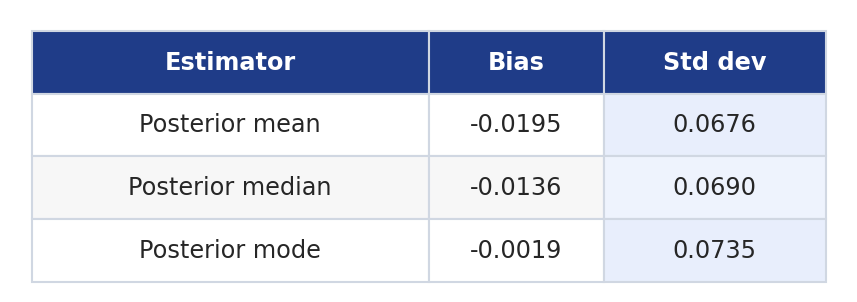

In [26]:
# Bias and standard deviation for posterior point estimators (across simulated datasets)
estimator_map = {
    "Posterior mean": "posterior_mean",
    "Posterior median": "posterior_median",
    "Posterior mode": "posterior_mode",
}

bias_var_table = pd.DataFrame(
    [
        {
            "Estimator": name,
            "Bias": summary_df[col].mean() - theta_real,
            "Std dev": summary_df[col].std(ddof=1),
        }
        for name, col in estimator_map.items()
    ]
)

bias_var_display = bias_var_table.copy()
bias_var_display["Bias"] = bias_var_display["Bias"].map(lambda value: f"{value:+.4f}")
bias_var_display["Std dev"] = bias_var_display["Std dev"].map(lambda value: f"{value:.4f}")

fig, ax = plt.subplots(figsize=(5.6, 1.9))
fig.patch.set_facecolor("white")
ax.axis("off")

bias_table = ax.table(
    cellText=bias_var_display.values,
    colLabels=bias_var_display.columns,
    colLoc="center",
    cellLoc="center",
    colWidths=[0.5, 0.22, 0.28],
    bbox=[0.02, 0.02, 0.96, 0.92],
)
bias_table.auto_set_font_size(False)
bias_table.set_fontsize(11.5)
bias_table.scale(1.0, 1.18)

header_color = "#1f3c88"
stripe_color = "#f7f7f7"
edge_color = "#d0d7e2"
std_highlight = "#e8eefc"

for (row, col), table_cell in bias_table.get_celld().items():
    table_cell.PAD = 0.018
    table_cell.set_edgecolor(edge_color)
    table_cell.set_linewidth(1.0)
    if row == 0:
        table_cell.set_facecolor(header_color)
        table_cell.set_text_props(color="white", weight="bold", fontsize=11.5)
    else:
        if row % 2 == 0:
            table_cell.set_facecolor(stripe_color)
        if col == 2:
            table_cell.set_facecolor(std_highlight if row % 2 == 1 else "#eef3fd")

plt.tight_layout(pad=0.25)
plt.show()

<a id="section-36"></a>
## 3.6 HDI
### High density intervals

- An HDI is the interval of highest posterior density that contains a chosen amount of probability mass.
- For a unimodal univariate posterior, the HDI is the shortest interval with that probability mass.
- In multimodal cases an HDI can be disconnected.
- Across repeated datasets, the HDI itself changes, so we can also study its long-run coverage behavior.

In [27]:
hdi_prob = 0.94
theta_grid = np.linspace(0, 1, 500)

hdi_intervals = np.array([
    np.asarray(az.hdi(samples, hdi_prob=hdi_prob))
    for samples in posterior_theta_samples
])

hdi_lower = hdi_intervals[:, 0]
hdi_upper = hdi_intervals[:, 1]
hdi_midpoint = 0.5 * (hdi_lower + hdi_upper)
posterior_mean_order = np.argsort(posterior_means)

sorted_hdi_lower = hdi_lower[posterior_mean_order]
sorted_hdi_upper = hdi_upper[posterior_mean_order]
sorted_posterior_means = posterior_means[posterior_mean_order]

hdi_membership = (
    (theta_grid[None, :] >= hdi_lower[:, None])
    & (theta_grid[None, :] <= hdi_upper[:, None])
).astype(float)
hdi_probability_curve = hdi_membership.mean(axis=0)

square_hdi_count = min(200, num_simulated_datasets)
square_row_indices = np.linspace(0, num_simulated_datasets - 1, square_hdi_count).round().astype(int)
square_rank_positions = square_row_indices + 1
square_theta_grid = np.linspace(0, 1, square_hdi_count)
square_hdi_lower = sorted_hdi_lower[square_row_indices]
square_hdi_upper = sorted_hdi_upper[square_row_indices]
square_hdi_membership = (
    (square_theta_grid[None, :] >= square_hdi_lower[:, None])
    & (square_theta_grid[None, :] <= square_hdi_upper[:, None])
).astype(float)

hdi_summary_df = pd.DataFrame({
    "posterior_mean": posterior_means,
    "hdi_lower": hdi_lower,
    "hdi_upper": hdi_upper,
    "hdi_width": hdi_upper - hdi_lower,
}).sort_values("posterior_mean").reset_index(drop=True)

hdi_summary_df.head()

,posterior_mean,hdi_lower,hdi_upper,hdi_width
0,0.532436,0.367988,0.695754,0.327766
1,0.563683,0.399325,0.715294,0.315969
2,0.593090,0.437090,0.761786,0.324696
3,0.593402,0.423810,0.747795,0.323985
4,0.593702,0.430610,0.759344,0.328734


C:\Users\User\AppData\Local\Temp\ipykernel_31560\4238363654.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


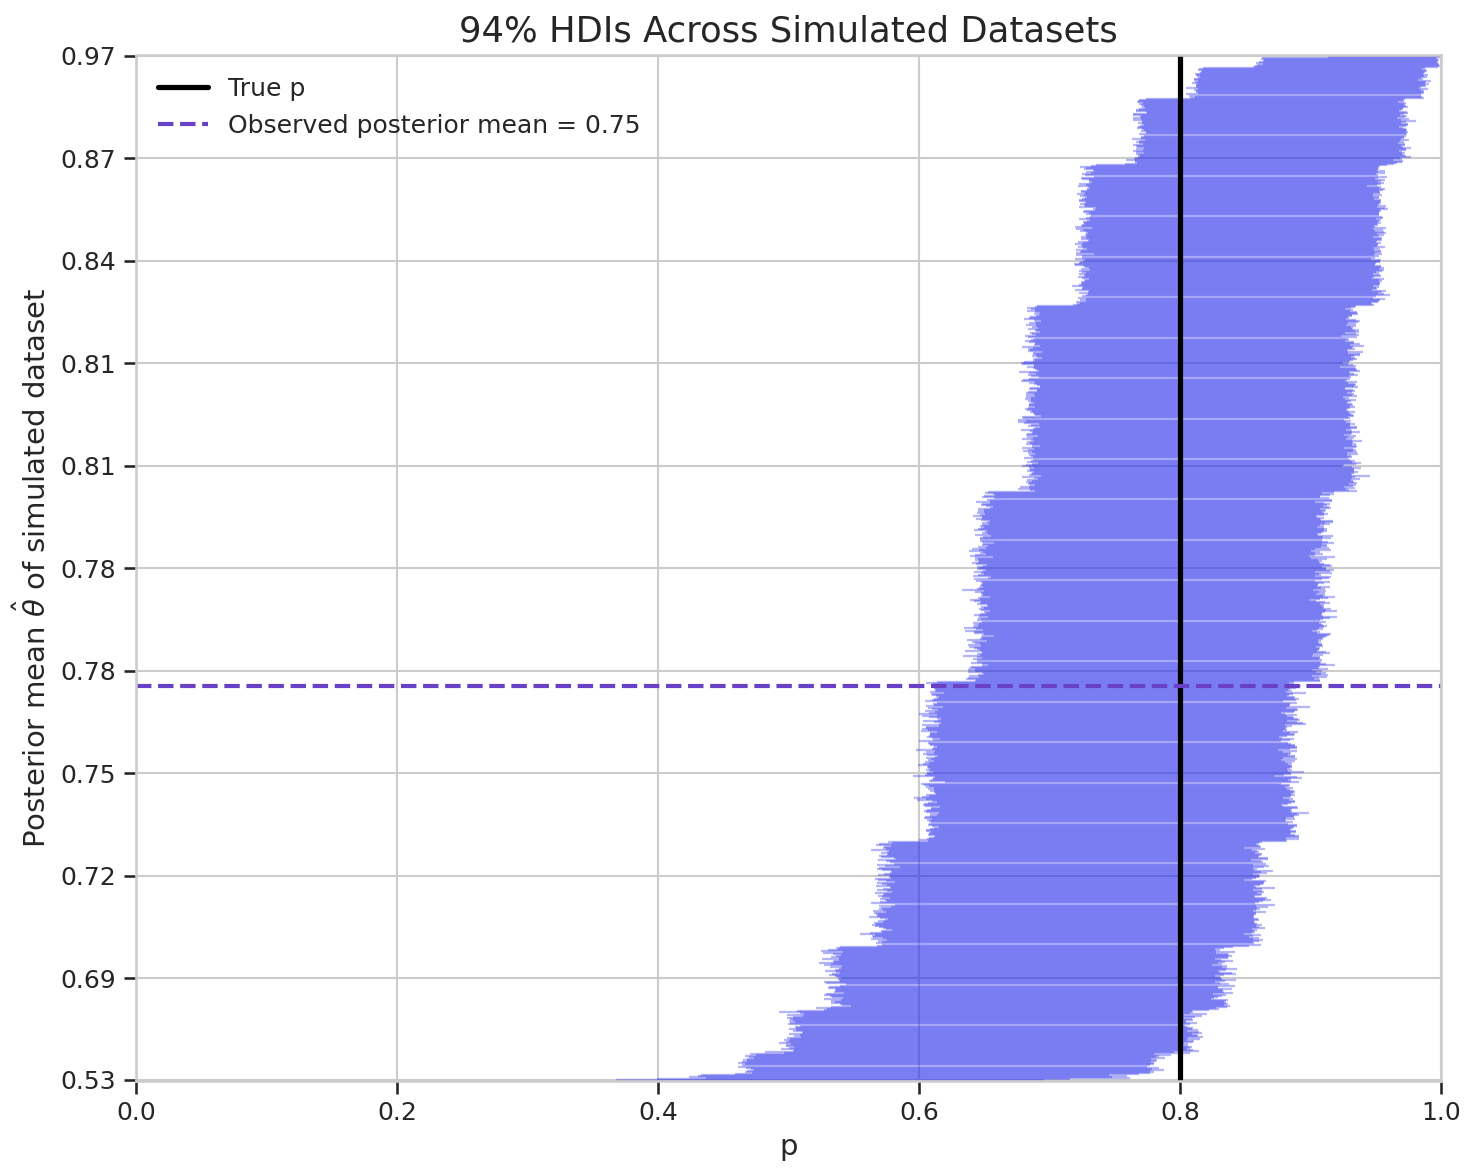

In [28]:
fig, ax = plt.subplots(figsize=(10, 8))
y_positions = np.arange(1, num_simulated_datasets + 1)

ax.hlines(
    y_positions,
    sorted_hdi_lower,
    sorted_hdi_upper,
    color="C0",
    linewidth=1.1,
    alpha=0.35,
)
ax.axvline(theta_real, color='black', linewidth=2.5, label='True p')

# Horizontal line at the rank of our observed dataset (sorted by posterior mean)
obs_lo = np.searchsorted(sorted_posterior_means, posterior_mean, side='left')
obs_hi = np.searchsorted(sorted_posterior_means, posterior_mean, side='right')
obs_rank_hdi = (obs_lo + obs_hi - 1) / 2 + 1  # y_positions starts at 1
ax.axhline(obs_rank_hdi, color='#6941c6', linestyle='--', linewidth=2.0,
           label=rf'Observed posterior mean = {posterior_mean:.2f}')

# Y-ticks labelled with posterior mean at that rank
tick_pos = np.linspace(1, num_simulated_datasets, 11, dtype=int)
tick_labels = [f'{sorted_posterior_means[p - 1]:.2f}' for p in tick_pos]
ax.set_yticks(tick_pos)
ax.set_yticklabels(tick_labels, fontsize=11)

ax.set_xlim(0, 1)
ax.set_ylim(0, num_simulated_datasets + 1)
ax.set_title(f"{int(hdi_prob * 100)}% HDIs Across Simulated Datasets", fontsize=17)
ax.set_xlabel("p", fontsize=14)
ax.set_ylabel(r"Posterior mean $\hat{\theta}$ of simulated dataset", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=12, loc='upper left')
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_31560\3728574019.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


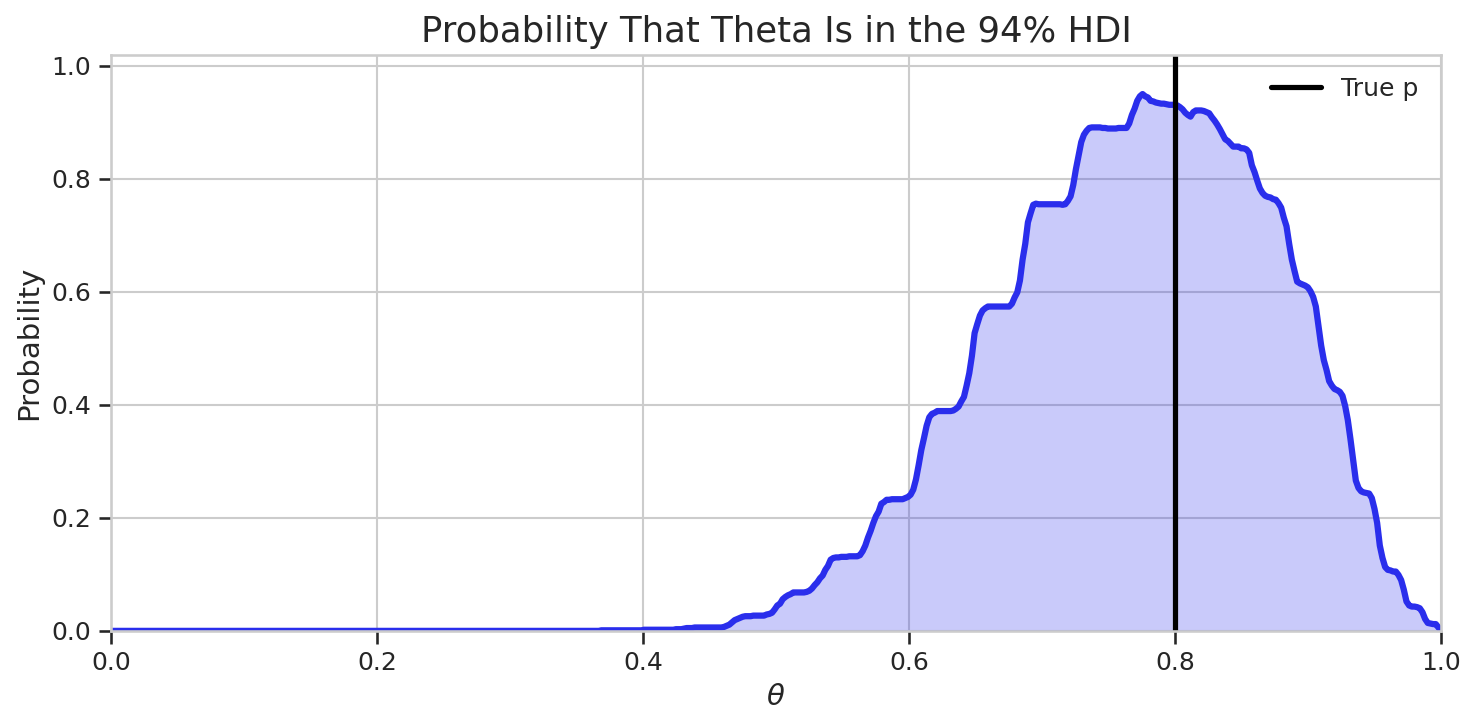

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(theta_grid, hdi_probability_curve, color="C0", linewidth=3)
ax.fill_between(theta_grid, 0, hdi_probability_curve, color="C0", alpha=0.25)
ax.axvline(theta_real, color="black", linewidth=2.5, label="True p")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_title(f"Probability That Theta Is in the {int(hdi_prob * 100)}% HDI", fontsize=17)
ax.set_xlabel(r"$\theta$", fontsize=14)
ax.set_ylabel("Probability", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

<a id="section-37"></a>
## 3.7 Frequentist vs Bayesian philosophies

### Bayesian view
- Data updates our understanding of the world rather than revealing truth directly.
- Parameters are treated as uncertain quantities, and probability distributions over parameters express that uncertainty.
- Priors encode knowledge before observing the data, and Bayesian updating combines that knowledge with new information.

### Frequentist view
- Parameters are fixed constants and the data are random.
- The goal is an objective procedure whose performance can be studied over repeated samples.
- Frequentist uncertainty is typically aleatory: it comes from real-world stochasticity rather than uncertainty about the parameter itself.

### Different questions
- Bayesian: given the model and the data, what should we believe about the parameter?
- Frequentist: if we repeated the procedure many times, how would the estimator behave?

<a id="section-38"></a>
## 3.8 Frequentist estimation

- A statistic is anything we calculate from the data; an estimator is a statistic used as a guess of a real value.
- For the mean, the slides contrast the sample mean, the sample median, and the reduced (trimmed) mean.
- When data are well behaved, those estimators are often similar; with small samples or outliers, the differences become much more visible.
- A key frequentist tool is the sampling distribution: how the estimator varies across repeated datasets.

In [30]:
cs_data = pd.read_csv(DATA_FILE_PATHS["chemical_shifts"])
diff = cs_data.theo - cs_data.exp

In [31]:
trimming = 0.2

sample_mean = np.mean(diff)
trimmed_mean = stats.trim_mean(diff, trimming)
sample_median = np.median(diff)
# Calculate additional statistics
sample_size = len(diff)
print(f"Sample Mean: {sample_mean:.4f}")
print(f"Trimmed Mean: {trimmed_mean:.4f}")
print(f"Sample Median: {sample_median:.4f}")

Sample Mean: 0.0516
Trimmed Mean: 0.0767
Sample Median: 0.0700


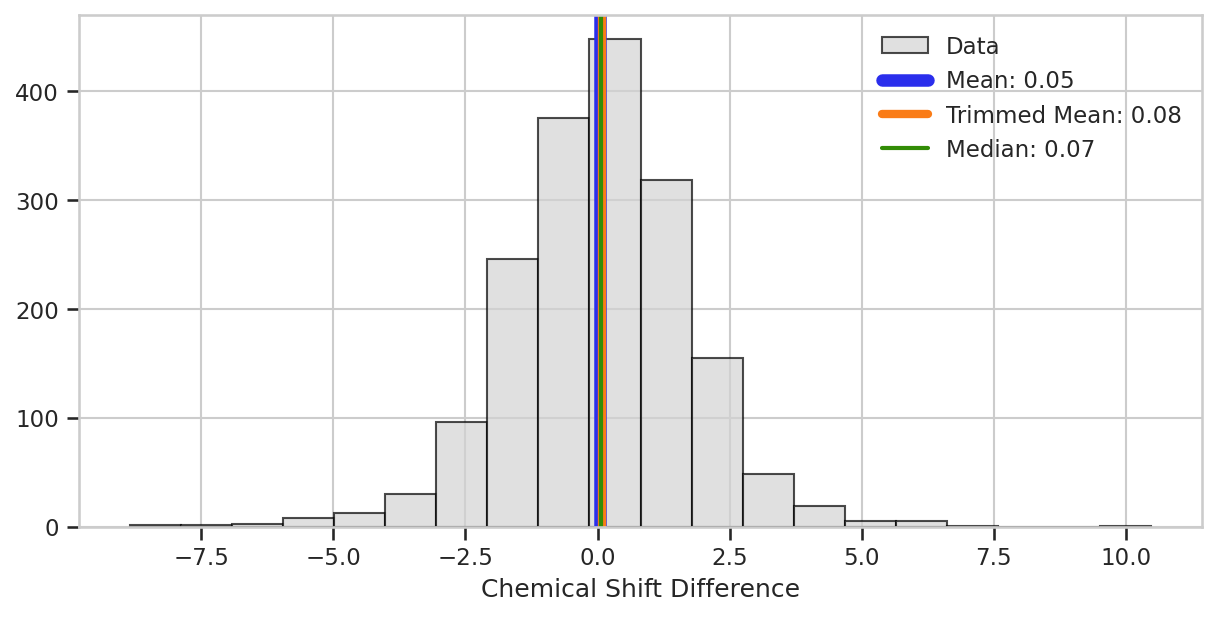

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(diff, bins=20, color='lightgray', edgecolor='black', alpha=0.7, label='Data')

sample_mean = np.mean(diff)
trimmed_mean = stats.trim_mean(diff, trimming)
sample_median = np.median(diff)

ax.axvline(sample_mean, color='C0', label=f'Mean: {sample_mean:.2f}', linewidth=6)
ax.axvline(trimmed_mean, color='C1', label=f'Trimmed Mean: {trimmed_mean:.2f}', linewidth=4)
ax.axvline(sample_median, color='C2', label=f'Median: {sample_median:.2f}', linewidth=2)

ax.set_xlabel('Chemical Shift Difference')
ax.legend()
plt.show()

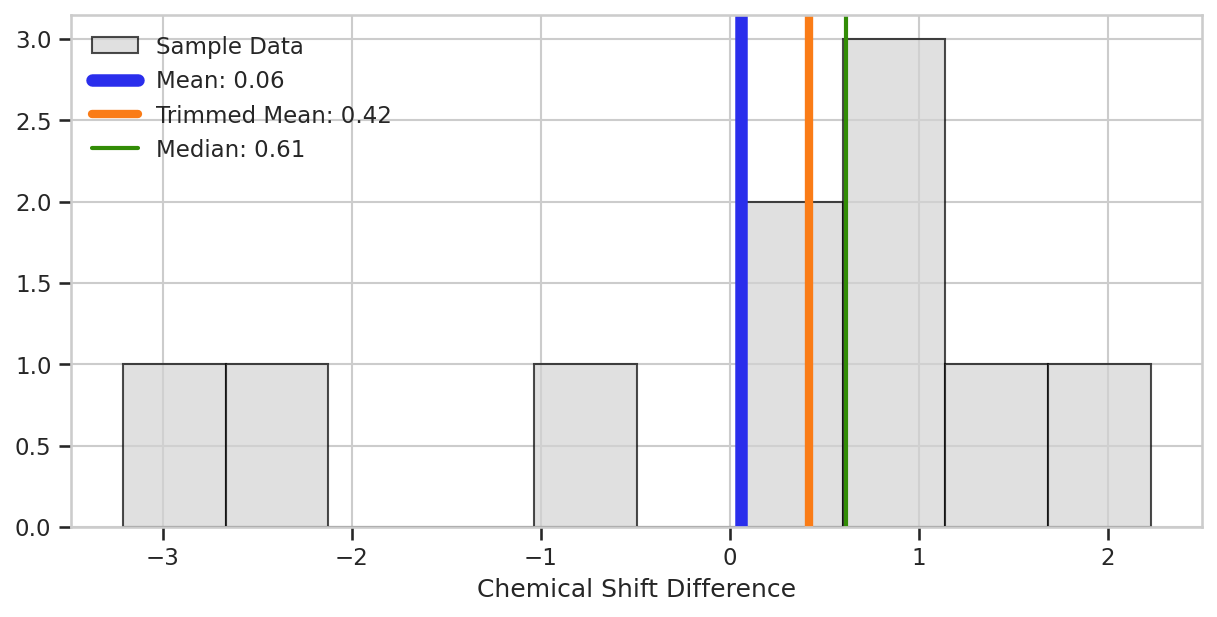

In [33]:
np.random.seed(456)
diff_sample = np.random.choice(diff, size=10, replace=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(diff_sample, bins=10, color='lightgray', edgecolor='black', alpha=0.7, label='Sample Data')

sample_mean_sample = np.mean(diff_sample)
trimmed_mean_sample = stats.trim_mean(diff_sample, trimming)
sample_median_sample = np.median(diff_sample)

ax.axvline(sample_mean_sample, color='C0', label=f'Mean: {sample_mean_sample:.2f}', linewidth=6)
ax.axvline(trimmed_mean_sample, color='C1', label=f'Trimmed Mean: {trimmed_mean_sample:.2f}', linewidth=4)
ax.axvline(sample_median_sample, color='C2', label=f'Median: {sample_median_sample:.2f}', linewidth=2)

ax.set_xlabel('Chemical Shift Difference')
ax.legend()
plt.show()

### Estimated sampling distributions for the example data
To mimic repeated sampling from the same study, we use bootstrap resamples of the observed chemical-shift differences. This gives an estimated sampling distribution for the sample mean, sample median, and a KDE-based sample mode.

In [34]:
bootstrap_reps = 2000
bootstrap_rng = np.random.default_rng(2026)
bootstrap_samples = bootstrap_rng.choice(diff.to_numpy(), size=(bootstrap_reps, sample_size), replace=True)

sampling_mean = bootstrap_samples.mean(axis=1)
sampling_median = np.median(bootstrap_samples, axis=1)

mode_grid = np.linspace(diff.min(), diff.max(), 512)

def kde_mode(values, grid):
    kde_x, kde_y = az.kde(values, custom_lims=(grid[0], grid[-1]))
    return float(kde_x[np.argmax(kde_y)])

sampling_mode = np.array([kde_mode(sample, mode_grid) for sample in bootstrap_samples])

observed_mode = kde_mode(diff.to_numpy(), mode_grid)

sampling_distribution_summary = pd.DataFrame(
    {
        "Estimator": ["Mean", "Median", "Mode"],
        "Observed value": [sample_mean, sample_median, observed_mode],
        "Sampling SD": [
            sampling_mean.std(ddof=1),
            sampling_median.std(ddof=1),
            sampling_mode.std(ddof=1),
        ],
    }
)

sampling_distribution_summary


,Estimator,Observed value,Sampling SD
0,Mean,0.051650,0.040772
1,Median,0.070000,0.049226
2,Mode,0.116553,0.177397


C:\Users\User\AppData\Local\Temp\ipykernel_31560\3224188862.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


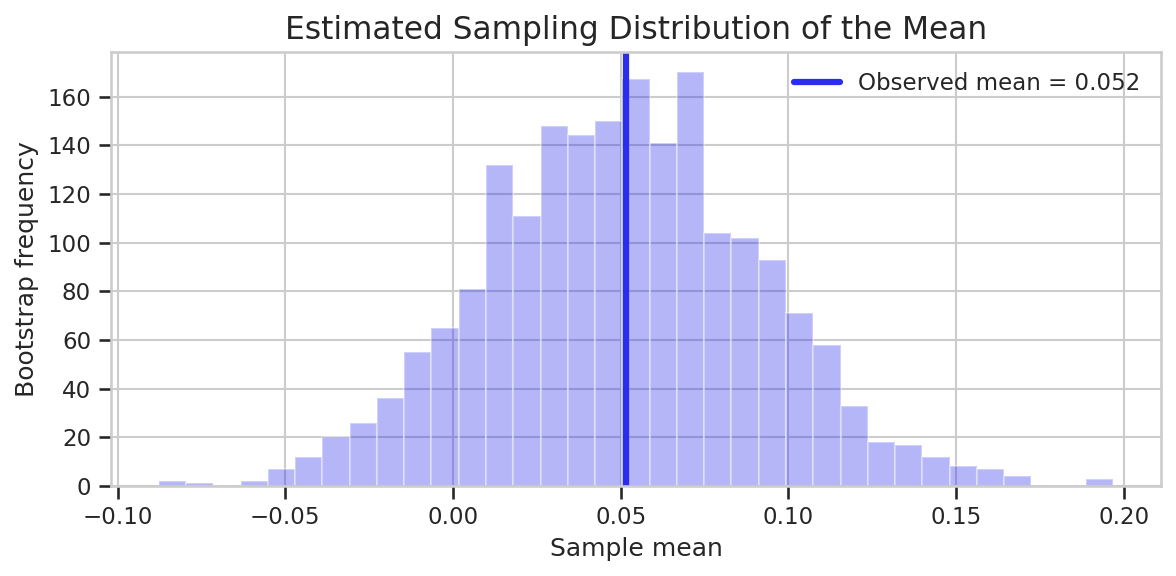

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sampling_mean, bins=35, color='C0', alpha=0.35, edgecolor='white')
ax.axvline(sample_mean, color='C0', linewidth=3, label=f'Observed mean = {sample_mean:.3f}')
ax.set_title('Estimated Sampling Distribution of the Mean', fontsize=15)
ax.set_xlabel('Sample mean', fontsize=12)
ax.set_ylabel('Bootstrap frequency', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_31560\1291774337.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


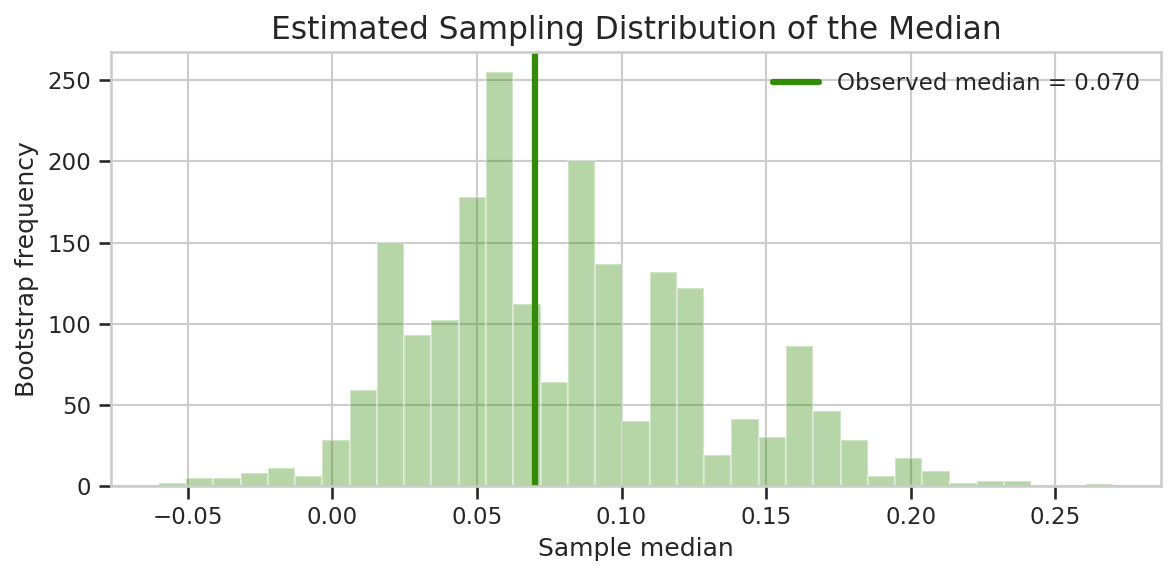

In [36]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sampling_median, bins=35, color='C2', alpha=0.35, edgecolor='white')
ax.axvline(sample_median, color='C2', linewidth=3, label=f'Observed median = {sample_median:.3f}')
ax.set_title('Estimated Sampling Distribution of the Median', fontsize=15)
ax.set_xlabel('Sample median', fontsize=12)
ax.set_ylabel('Bootstrap frequency', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_31560\4046339257.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


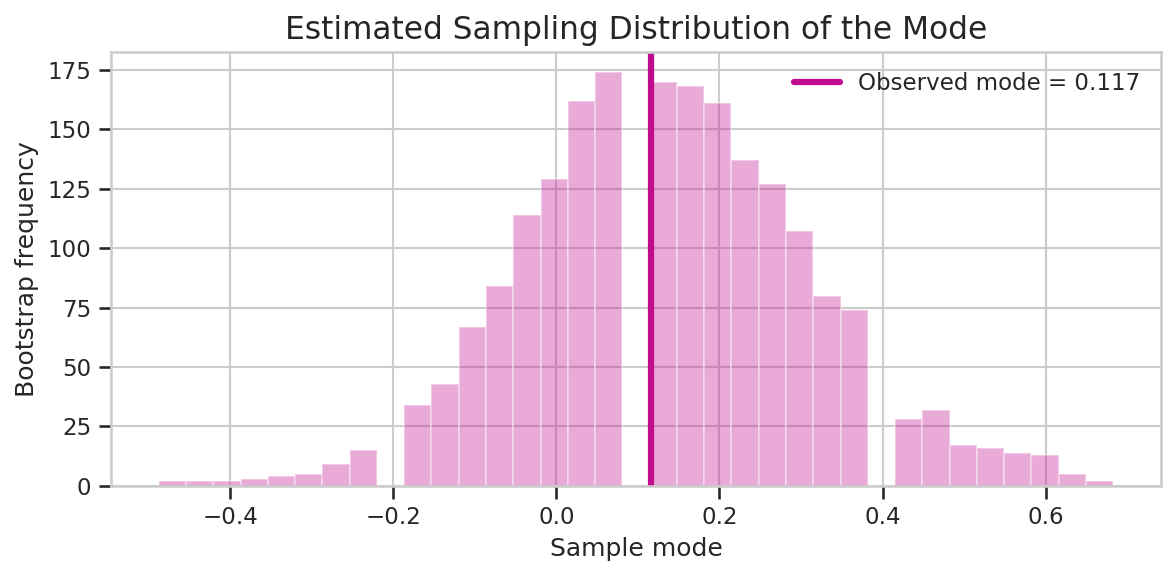

In [37]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sampling_mode, bins=35, color='C3', alpha=0.35, edgecolor='white')
ax.axvline(observed_mode, color='C3', linewidth=3, label=f'Observed mode = {observed_mode:.3f}')
ax.set_title('Estimated Sampling Distribution of the Mode', fontsize=15)
ax.set_xlabel('Sample mode', fontsize=12)
ax.set_ylabel('Bootstrap frequency', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_31560\115927907.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0.25)


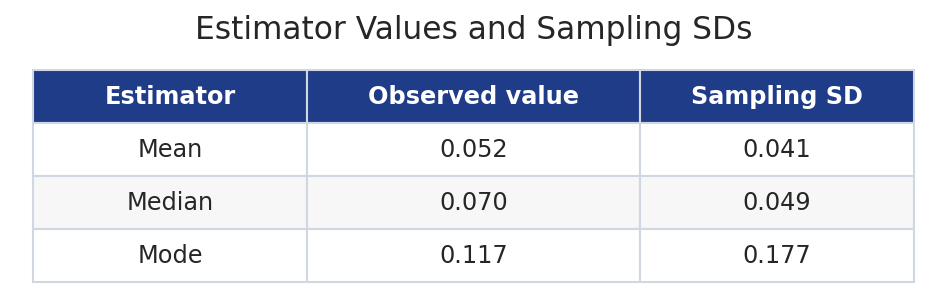

In [38]:
sampling_distribution_display = sampling_distribution_summary.copy()
sampling_distribution_display['Observed value'] = sampling_distribution_display['Observed value'].map(lambda value: f'{value:.3f}')
sampling_distribution_display['Sampling SD'] = sampling_distribution_display['Sampling SD'].map(lambda value: f'{value:.3f}')

fig, ax = plt.subplots(figsize=(6.2, 1.9))
fig.patch.set_facecolor('white')
ax.axis('off')

summary_table = ax.table(
    cellText=sampling_distribution_display.values,
    colLabels=sampling_distribution_display.columns,
    colLoc='center',
    cellLoc='center',
    colWidths=[0.28, 0.34, 0.28],
    bbox=[0.02, 0.02, 0.96, 0.9],
)
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(11.5)
summary_table.scale(1.0, 1.18)

for (row, col), table_cell in summary_table.get_celld().items():
    table_cell.set_edgecolor('#d0d7e2')
    table_cell.set_linewidth(1.0)
    if row == 0:
        table_cell.set_facecolor('#1f3c88')
        table_cell.set_text_props(color='white', weight='bold')
    elif row % 2 == 0:
        table_cell.set_facecolor('#f7f7f7')

ax.set_title('Estimator Values and Sampling SDs', fontsize=15, pad=6)
plt.tight_layout(pad=0.25)
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_31560\1948966131.py:95: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0.35)


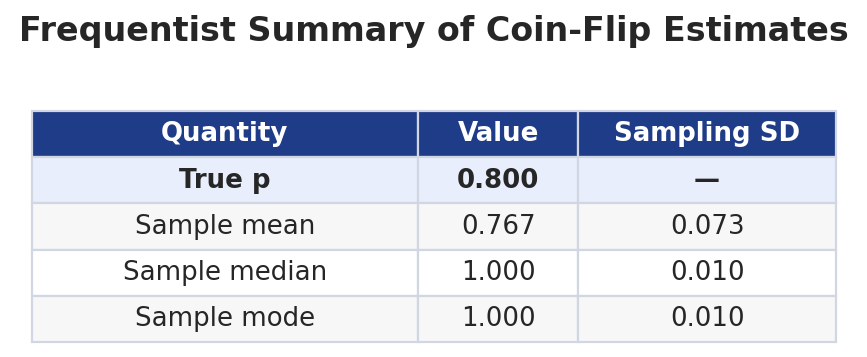

In [39]:
coin_flip_sample_size = len(data)
coin_flip_heads_observed = int(np.sum(data))

def bernoulli_sample_median_from_heads(heads, n):
    half = n / 2
    if heads < half:
        return 0.0
    if heads > half:
        return 1.0
    return 0.5

def bernoulli_sample_mode_from_heads(heads, n):
    half = n / 2
    if heads < half:
        return 0.0
    if heads > half:
        return 1.0
    # For an exact tie, record 0.5 so the estimator stays single-valued.
    return 0.5

coin_flip_mean = coin_flip_heads_observed / coin_flip_sample_size
coin_flip_median = bernoulli_sample_median_from_heads(coin_flip_heads_observed, coin_flip_sample_size)
coin_flip_mode = bernoulli_sample_mode_from_heads(coin_flip_heads_observed, coin_flip_sample_size)

head_support = np.arange(coin_flip_sample_size + 1)
head_pmf = stats.binom.pmf(head_support, coin_flip_sample_size, theta_real)

mean_support = head_support / coin_flip_sample_size
median_support = np.array([
    bernoulli_sample_median_from_heads(heads, coin_flip_sample_size)
    for heads in head_support
])
mode_support = np.array([
    bernoulli_sample_mode_from_heads(heads, coin_flip_sample_size)
    for heads in head_support
])

def exact_sampling_sd(values, probs):
    expected_value = np.sum(values * probs)
    return np.sqrt(np.sum(((values - expected_value) ** 2) * probs))

frequentist_coin_summary = pd.DataFrame({
    "Quantity": ["True p", "Sample mean", "Sample median", "Sample mode"],
    "Value": [theta_real, coin_flip_mean, coin_flip_median, coin_flip_mode],
    "Sampling SD": [
        "—",
        exact_sampling_sd(mean_support, head_pmf),
        exact_sampling_sd(median_support, head_pmf),
        exact_sampling_sd(mode_support, head_pmf),
    ],
})

frequentist_coin_display = frequentist_coin_summary.copy()
frequentist_coin_display["Value"] = frequentist_coin_display["Value"].map(lambda value: f"{value:.3f}")
frequentist_coin_display["Sampling SD"] = [
    value if isinstance(value, str) else f"{value:.3f}"
    for value in frequentist_coin_summary["Sampling SD"]
]

fig, ax = plt.subplots(figsize=(5.7, 2.3))
fig.patch.set_facecolor("white")
ax.axis("off")

summary_table = ax.table(
    cellText=frequentist_coin_display.values,
    colLabels=frequentist_coin_display.columns,
    colLoc="center",
    cellLoc="center",
    colWidths=[0.48, 0.2, 0.32],
    bbox=[0.02, 0.0, 0.96, 0.8],
)
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(12.5)
summary_table.scale(1.0, 1.22)

header_color = "#1f3c88"
highlight_color = "#e8eefc"
stripe_color = "#f7f7f7"
edge_color = "#d0d7e2"

for (row, col), table_cell in summary_table.get_celld().items():
    table_cell.PAD = 0.02
    table_cell.set_edgecolor(edge_color)
    table_cell.set_linewidth(1.05)
    if row == 0:
        table_cell.set_facecolor(header_color)
        table_cell.set_text_props(color="white", weight="bold", fontsize=12.5)
    elif row == 1:
        table_cell.set_facecolor(highlight_color)
        table_cell.set_text_props(weight="bold")
    elif row % 2 == 0:
        table_cell.set_facecolor(stripe_color)

ax.set_title("Frequentist Summary of Coin-Flip Estimates", fontsize=16, fontweight="bold", pad=6)
plt.tight_layout(pad=0.35)
plt.show()

<a id="section-39"></a>
## 3.9 Maximum likelihood

- The MLE is the parameter value that makes the observed data most believable under the model.
- We can obtain an MLE analytically for some simple likelihoods, or numerically when the likelihood is more complicated.
- Advantages highlighted in the slides include consistency, efficiency, and flexibility.
- Important limitations are sensitivity to misspecification, sensitivity to outliers, and computational cost.
- With a flat prior, the posterior mode coincides with the MLE.

In [40]:
mean_mle = np.mean(diff)
std_mle = np.std(diff, ddof=0)

print(f"MLE Mean: {mean_mle:.4f}")

# Approximate a posterior for the mean and compare its mode with the MLE.
with pm.Model() as model:
    mu = pm.Normal("mu", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)
    y = pm.Normal("y", mu=mu, sigma=sigma, observed=diff)
    trace = pm.sample(1000, tune=1000, chains=2, random_seed=123, return_inferencedata=True)

posterior_samples = trace.posterior["mu"].values.flatten()
kde_x, kde_y = az.kde(posterior_samples)
posterior_mode = kde_x[np.argmax(kde_y)]
print(f"Posterior mode estimate: {posterior_mode:.4f}")


Initializing NUTS using jitter+adapt_diag...


MLE Mean: 0.0516


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 31 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Posterior mode estimate: 0.0442


C:\Users\User\AppData\Local\Temp\ipykernel_31560\341517260.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


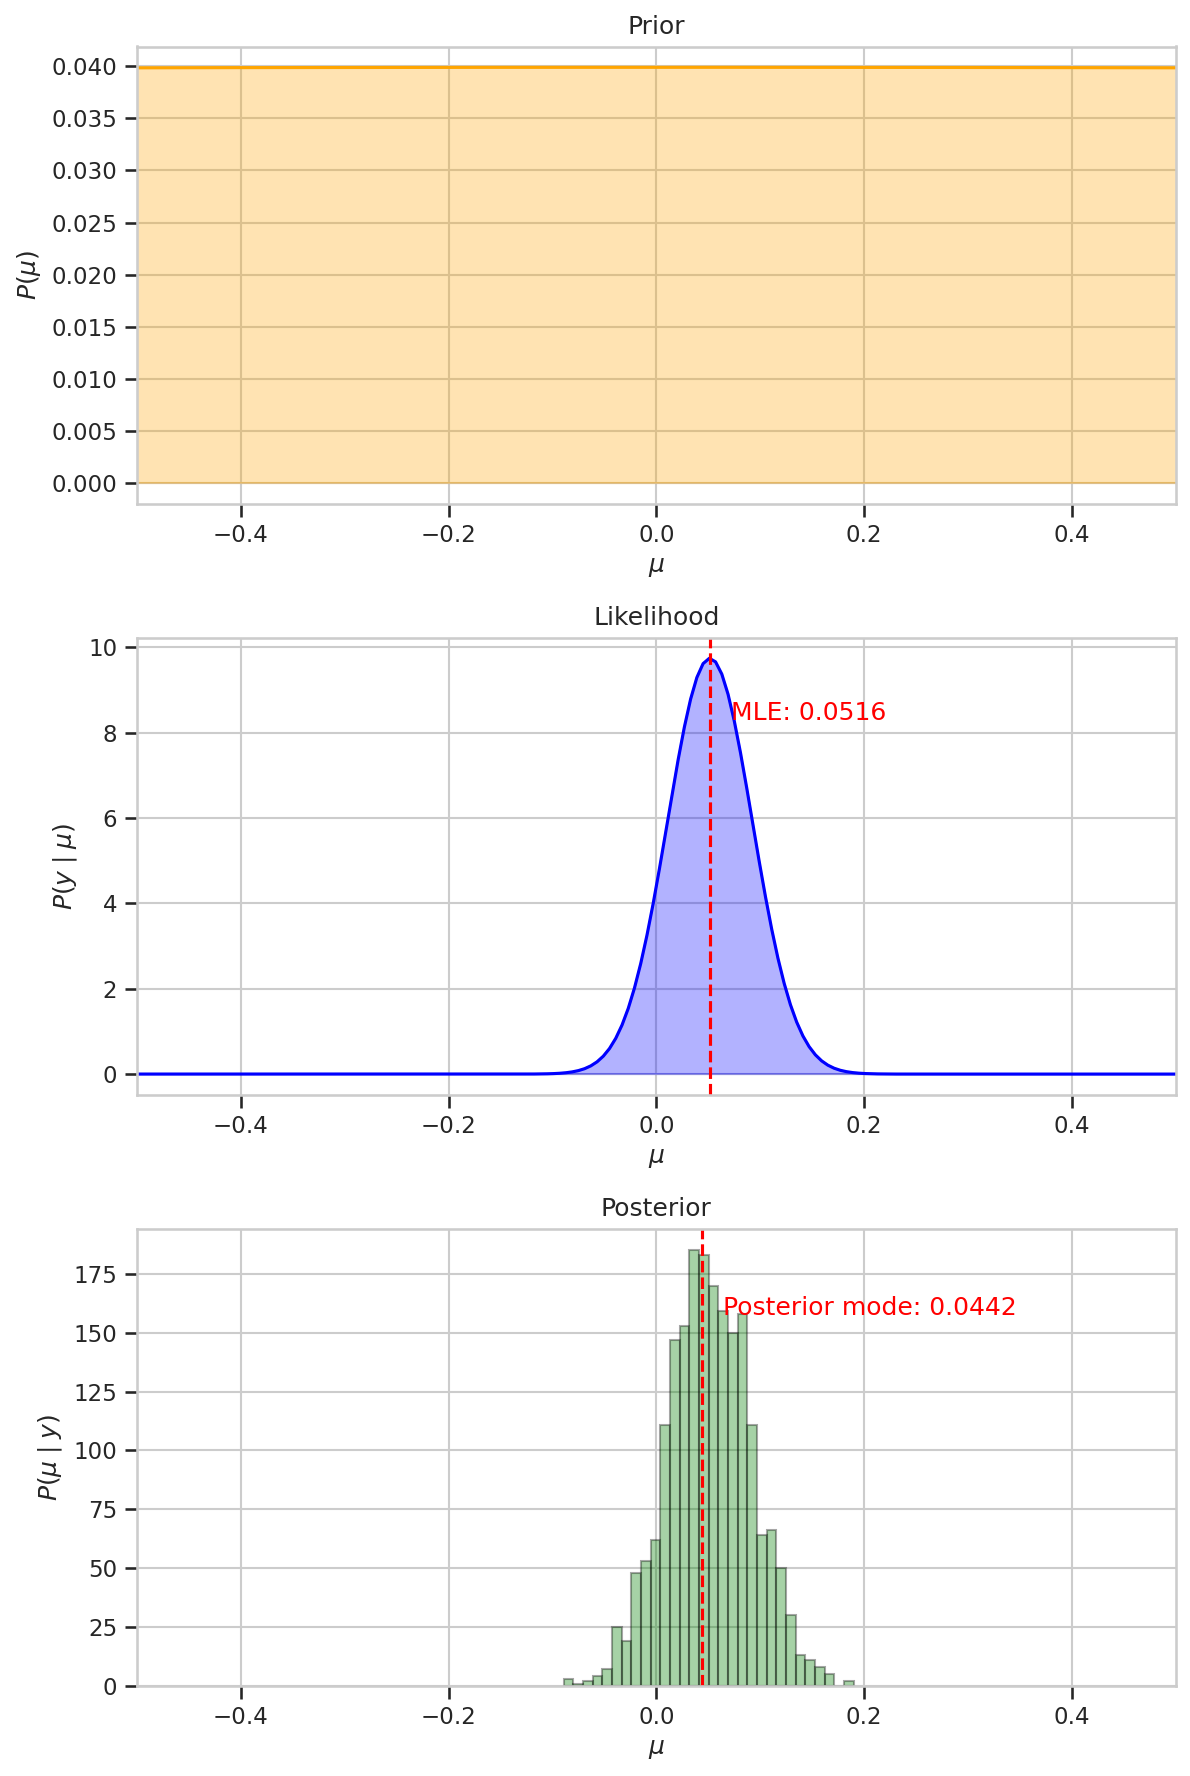

In [41]:
# Prior
mu_range = np.linspace(-3, 3, 1000)
prior_pdf = stats.norm.pdf(mu_range, loc=0, scale=10)

# Likelihood
likelihood_pdf = stats.norm.pdf(mu_range, loc=mean_mle, scale=std_mle / np.sqrt(len(diff)))

# Plot
fig, axes = plt.subplots(3, 1, figsize=(8, 12))
xlim = [-0.5, 0.5]

# Prior plot
axes[0].plot(mu_range, prior_pdf, color="orange")
axes[0].fill_between(mu_range, 0, prior_pdf, color="orange", alpha=0.3)
axes[0].set_xlim(xlim)
axes[0].set_title("Prior")
axes[0].set_xlabel(r"$\mu$")
axes[0].set_ylabel(r"$P(\mu)$")

# Likelihood plot
axes[1].plot(mu_range, likelihood_pdf, color="blue")
axes[1].fill_between(mu_range, 0, likelihood_pdf, color="blue", alpha=0.3)
axes[1].axvline(mean_mle, color="red", linestyle="--")
axes[1].text(mean_mle + 0.02, axes[1].get_ylim()[1] * 0.8, f"MLE: {mean_mle:.4f}", color="red", ha="left", va="bottom")
axes[1].set_xlim(xlim)
axes[1].set_title("Likelihood")
axes[1].set_xlabel(r"$\mu$")
axes[1].set_ylabel(r"$P(y\mid\mu)$")

# Posterior plot
axes[2].hist(posterior_samples, bins=30, color="green", alpha=0.35, edgecolor="black")
axes[2].axvline(posterior_mode, color="red", linestyle="--")
axes[2].text(posterior_mode + 0.02, axes[2].get_ylim()[1] * 0.8, f"Posterior mode: {posterior_mode:.4f}", color="red", ha="left", va="bottom")
axes[2].set_xlim(xlim)
axes[2].set_title("Posterior")
axes[2].set_xlabel(r"$\mu$")
axes[2].set_ylabel(r"$P(\mu\mid y)$")
axes[2].grid(axis="both", visible=True)

plt.tight_layout()
plt.show()


<a id="section-310"></a>
## 3.10 Confidence intervals

### Credible intervals vs confidence intervals
The slides derive confidence intervals from tail probabilities of the sampling distribution. In this section we use a 96% confidence interval built from 2% tails, then compare that frequentist logic with the earlier HDI-based Bayesian summaries.

C:\Users\User\AppData\Local\Temp\ipykernel_31560\716969899.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


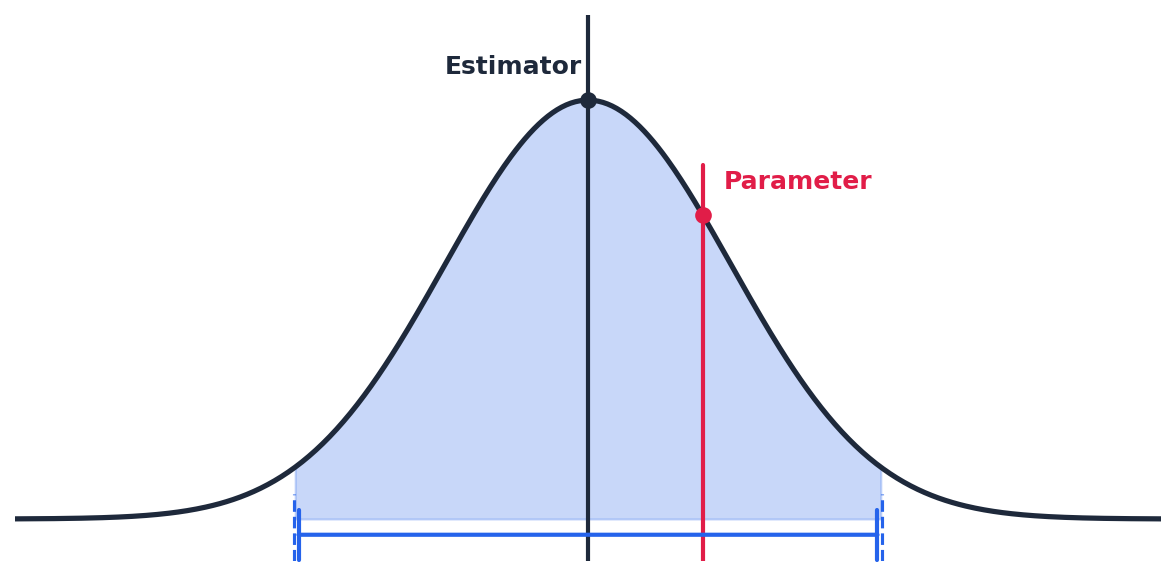

In [42]:
fig, ax = plt.subplots(figsize=(8, 4))

dist = pz.Normal(0, 1)

x = np.linspace(-4, 4, 500)
y = dist.pdf(x)

lo, hi = -2.05, 2.05
param_loc = theta_real  # true parameter location used in the simulated examples

# Shaded interval
ax.fill_between(x, y, where=(x >= lo) & (x <= hi),
                color='#2563eb', alpha=0.25)

# Curve
ax.plot(x, y, color='#1e293b', linewidth=2.5)

# Dashed vertical lines at interval edges
for v in [lo, hi]:
    ax.axvline(v, ymin=0, ymax=dist.pdf(v)/max(y),
               color='#2563eb', linewidth=1.5, linestyle='--')

# Bracket below x-axis
y_bracket = -0.015
ax.annotate('', xy=(hi, y_bracket), xytext=(lo, y_bracket),
            arrowprops=dict(arrowstyle='|-|', color='#2563eb', lw=2))

# Estimator — peak
ax.plot(0, dist.pdf(0), 'o', color='#1e293b', markersize=7)
ax.text(-0.04, dist.pdf(0) + 0.02, 'Estimator', ha='right', va='bottom',
        fontsize=12, color='#1e293b', fontweight='bold')
ax.axvline(0, ymin=0, ymax=dist.pdf(0)/max(y),
           color='#1e293b', linewidth=2, linestyle='-')

# Parameter — arbitrary location
ax.axvline(param_loc, ymin=0, ymax=dist.pdf(param_loc)/max(y),
           color='#e11d48', linewidth=2, linestyle='-')
ax.plot(param_loc, dist.pdf(param_loc), 'o', color='#e11d48', markersize=7)
ax.text(param_loc + 0.15, dist.pdf(param_loc) + 0.02, 'Parameter', ha='left',
        va='bottom', fontsize=12, color='#e11d48', fontweight='bold')

# Clean up
ax.set_xlim(-4, 4)
ax.set_ylim(-0.04, 0.48)
ax.axis('off')

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_31560\3050211969.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0.3)


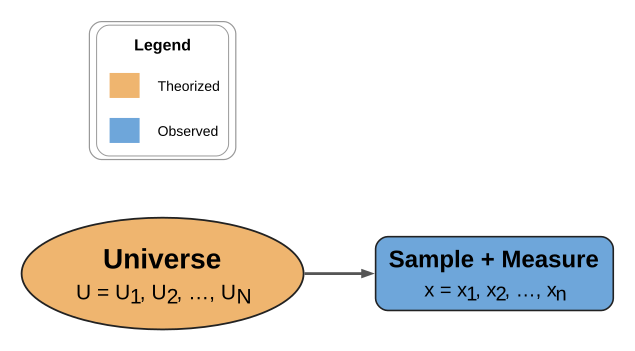

In [43]:
from graphviz import Digraph
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------------
# Create helper image for the sampling distribution with axis labels
# ------------------------------------------------------------------
out_dir = Path("graphviz_assets")
out_dir.mkdir(exist_ok=True)

curve_path = out_dir / "normal_curve.png"

x = np.linspace(-3.5, 3.5, 500)
y = np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)

fig, ax = plt.subplots(figsize=(4.5, 3), dpi=200)
ax.plot(x, y, lw=3, color="#222222")
ax.fill_between(x, 0, y, alpha=0.18, color="#222222")
ax.axhline(0, lw=1, color="#222222")
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(0, y.max() * 1.18)
ax.set_xlabel("Statistic", fontsize=14, fontweight="bold")
ax.set_ylabel("Probability Density", fontsize=14, fontweight="bold")
ax.tick_params(labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout(pad=0.3)
fig.savefig(curve_path, transparent=True, bbox_inches="tight", pad_inches=0.05, dpi=200)
plt.close(fig)

# ------------------------------------------------------------------
# Figure 1: Universe and one sample
# ------------------------------------------------------------------
pic1 = Digraph(format="svg")
pic1.attr(
    layout="dot",
    rankdir="LR",
    bgcolor="transparent",
    pad="0.3",
    nodesep="0.8",
    ranksep="1.0",
    splines="polyline",
)
pic1.attr("node", fontname="Arial", fontsize="22", color="#222222")
pic1.attr("edge", color="#555555", penwidth="2.8", arrowsize="0.8")

# Universe
universe_label_1 = (
    '<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="3">'
    '<TR><TD><FONT POINT-SIZE="28"><B>Universe</B></FONT></TD></TR>'
    '<TR><TD><FONT POINT-SIZE="21">U = U<SUB>1</SUB>, U<SUB>2</SUB>, …, U<SUB>N</SUB></FONT></TD></TR>'
    '</TABLE>'
)
pic1.node(
    "universe", f"<{universe_label_1}>",
    shape="ellipse", style="filled", fillcolor="#efb56f",
    color="#222222", penwidth="1.8", width="2.7", height="1.45", margin="0.14,0.08",
)

# One sample
sample_label_1 = (
    '<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="3">'
    '<TR><TD><FONT POINT-SIZE="24"><B>Sample + Measure</B></FONT></TD></TR>'
    '<TR><TD><FONT POINT-SIZE="20">x = x<SUB>1</SUB>, x<SUB>2</SUB>, …, x<SUB>n</SUB></FONT></TD></TR>'
    '</TABLE>'
)
pic1.node(
    "sample1", f"<{sample_label_1}>",
    shape="box", style="rounded,filled", fillcolor="#6ea6da",
    color="#222222", penwidth="1.6", width="3.1", height="0.95", margin="0.14,0.08",
)

pic1.edge("universe", "sample1")

# Add legend to pic1
legend_html_1 = (
    '<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="4" CELLPADDING="6" STYLE="rounded">' 
    '<TR><TD COLSPAN="2" ALIGN="CENTER"><FONT POINT-SIZE="16"><B>Legend</B></FONT></TD></TR>'
    '<TR><TD><TABLE BORDER="0" CELLPADDING="3"><TR><TD BGCOLOR="#efb56f" WIDTH="30" HEIGHT="25"></TD></TR></TABLE></TD>'
    '<TD ALIGN="LEFT"><FONT POINT-SIZE="14">Theorized</FONT></TD></TR>'
    '<TR><TD><TABLE BORDER="0" CELLPADDING="3"><TR><TD BGCOLOR="#6ea6da" WIDTH="30" HEIGHT="25"></TD></TR></TABLE></TD>'
    '<TD ALIGN="LEFT"><FONT POINT-SIZE="14">Observed</FONT></TD></TR>'
    '</TABLE>'
)
pic1.node("legend_1", f"<{legend_html_1}>", shape="box", style="rounded,filled", fillcolor="white", color="#999999", penwidth="1.2", margin="0.1,0.05")

# ------------------------------------------------------------------
# Figure 2: Universe and all samples
# ------------------------------------------------------------------
pic2 = Digraph(format="svg")
pic2.attr(
    layout="dot",
    rankdir="LR",
    bgcolor="transparent",
    pad="0.3",
    nodesep="0.6",
    ranksep="0.9",
    splines="polyline",
)
pic2.attr("node", fontname="Arial", fontsize="22", color="#222222")
pic2.attr("edge", color="#555555", penwidth="2.8", arrowsize="0.8")

# Universe
universe_label_2 = (
    '<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="3">'
    '<TR><TD><FONT POINT-SIZE="28"><B>Universe</B></FONT></TD></TR>'
    '<TR><TD><FONT POINT-SIZE="21">U = U<SUB>1</SUB>, U<SUB>2</SUB>, …, U<SUB>N</SUB></FONT></TD></TR>'
    '</TABLE>'
)
pic2.node(
    "universe", f"<{universe_label_2}>",
    shape="ellipse", style="filled", fillcolor="#efb56f",
    color="#222222", penwidth="1.8", width="2.7", height="1.45", margin="0.14,0.08",
)

# All samples
sample_label_2 = (
    '<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="3">'
    '<TR><TD><FONT POINT-SIZE="24"><B>Sample + Measure</B></FONT></TD></TR>'
    '<TR><TD><FONT POINT-SIZE="20">x = x<SUB>1</SUB>, x<SUB>2</SUB>, …, x<SUB>n</SUB></FONT></TD></TR>'
    '</TABLE>'
)

for i in range(1, 5):
    if i == 1:
        fillcolor = "#6ea6da"
    else:
        fillcolor = "#b397f9"
    pic2.node(
        f"sample{i}", f"<{sample_label_2}>",
        shape="box", style="rounded,filled", fillcolor=fillcolor,
        color="#222222", penwidth="1.6", width="3.1", height="0.95", margin="0.14,0.08",
    )


# Force vertical alignment
with pic2.subgraph() as s:
    s.attr(rank="same")
    for i in range(1, 5):
        s.node(f"sample{i}")

# Invisible collector
pic2.node("collect", "", shape="point", width="0.01", style="invis")

# Edges
for i in range(1, 5):
    pic2.edge("universe", f"sample{i}")

# Add legend to pic2
legend_html_2 = (
    '<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="4" CELLPADDING="6" STYLE="rounded">' 
    '<TR><TD COLSPAN="2" ALIGN="CENTER"><FONT POINT-SIZE="16"><B>Legend</B></FONT></TD></TR>'
    '<TR><TD><TABLE BORDER="0" CELLPADDING="3"><TR><TD BGCOLOR="#efb56f" WIDTH="30" HEIGHT="25"></TD></TR></TABLE></TD>'
    '<TD ALIGN="LEFT"><FONT POINT-SIZE="14">Theorized</FONT></TD></TR>'
    '<TR><TD><TABLE BORDER="0" CELLPADDING="3"><TR><TD BGCOLOR="#6ea6da" WIDTH="30" HEIGHT="25"></TD></TR></TABLE></TD>'
    '<TD ALIGN="LEFT"><FONT POINT-SIZE="14">Observed</FONT></TD></TR>'
    '<TR><TD><TABLE BORDER="0" CELLPADDING="3"><TR><TD BGCOLOR="#b397f9" WIDTH="30" HEIGHT="25"></TD></TR></TABLE></TD>'
    '<TD ALIGN="LEFT"><FONT POINT-SIZE="14">Replicated</FONT></TD></TR>'
    '</TABLE>'
)
pic2.node("legend_2", f"<{legend_html_2}>", shape="box", style="rounded,filled", fillcolor="white", color="#999999", penwidth="1.2", margin="0.1,0.05")

# ------------------------------------------------------------------
# Figure 3: All three (Universe, Samples, and Distribution)
# ------------------------------------------------------------------
pic3 = Digraph(format="svg")
pic3.attr(
    layout="dot",
    rankdir="LR",
    bgcolor="transparent",
    pad="0.3",
    nodesep="0.6",
    ranksep="0.9",
    splines="polyline",
)
pic3.attr("node", fontname="Arial", fontsize="22", color="#222222")
pic3.attr("edge", color="#555555", penwidth="2.8", arrowsize="0.8")

# Universe
universe_label_3 = (
    '<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="3">'
    '<TR><TD><FONT POINT-SIZE="28"><B>Universe</B></FONT></TD></TR>'
    '<TR><TD><FONT POINT-SIZE="21">U = U<SUB>1</SUB>, U<SUB>2</SUB>, …, U<SUB>N</SUB></FONT></TD></TR>'
    '</TABLE>'
)
pic3.node(
    "universe", f"<{universe_label_3}>",
    shape="ellipse", style="filled", fillcolor="#efb56f",
    color="#222222", penwidth="1.8", width="2.7", height="1.45", margin="0.14,0.08",
)

# All samples
sample_label_3 = (
    '<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="3">'
    '<TR><TD><FONT POINT-SIZE="24"><B>Sample + Measure</B></FONT></TD></TR>'
    '<TR><TD><FONT POINT-SIZE="20">x = x<SUB>1</SUB>, x<SUB>2</SUB>, …, x<SUB>n</SUB></FONT></TD></TR>'
    '</TABLE>'
)

for i in range(1, 5):
    if i == 1:
        fillcolor = "#6ea6da"
    else:
        fillcolor = "#b397f9"
    pic3.node(
        f"sample{i}", f"<{sample_label_3}>",
        shape="box", style="rounded,filled", fillcolor=fillcolor,
        color="#222222", penwidth="1.6", width="3.1", height="0.95", margin="0.14,0.08",
    )

# Invisible collector
pic3.node("collect", "", shape="point", width="0.01", style="invis")

# Distribution with axis labels
dist_label = (
    '<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="6">'
    '<TR><TD><FONT POINT-SIZE="24"><B>Sampling distribution</B></FONT></TD></TR>'
    f'<TR><TD><IMG SRC="{curve_path.as_posix()}" SCALE="TRUE"/></TD></TR>'
    '</TABLE>'
)
pic3.node(
    "dist", f"<{dist_label}>",
    shape="box", style="rounded,filled", fillcolor="white",
    color="#666666", penwidth="1.4", margin="0.10,0.08",
)

# Force vertical alignment of samples
with pic3.subgraph() as s:
    s.attr(rank="same")
    for i in range(1, 5):
        s.node(f"sample{i}")
# Edges: universe to samples
# Edges: universe to samples
    pic3.edge("universe", f"sample{i}")
# Edges: universe to samples
for i in range(1, 5):
    pic3.edge("universe", f"sample{i}")

# Edges: samples to collector
for i in range(1, 5):
    pic3.edge(f"sample{i}", "collect")

# Edge: collector to distribution
pic3.edge("collect", "dist")

# Add legend to pic3
legend_html_3 = (
    '<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="4" CELLPADDING="6" STYLE="rounded">' 
    '<TR><TD COLSPAN="2" ALIGN="CENTER"><FONT POINT-SIZE="16"><B>Legend</B></FONT></TD></TR>'
    '<TR><TD><TABLE BORDER="0" CELLPADDING="3"><TR><TD BGCOLOR="#efb56f" WIDTH="30" HEIGHT="25"></TD></TR></TABLE></TD>'
    '<TD ALIGN="LEFT"><FONT POINT-SIZE="14">Theorized</FONT></TD></TR>'
    '<TR><TD><TABLE BORDER="0" CELLPADDING="3"><TR><TD BGCOLOR="#6ea6da" WIDTH="30" HEIGHT="25"></TD></TR></TABLE></TD>'
    '<TD ALIGN="LEFT"><FONT POINT-SIZE="14">Observed</FONT></TD></TR>'
    '<TR><TD><TABLE BORDER="0" CELLPADDING="3"><TR><TD BGCOLOR="#b397f9" WIDTH="30" HEIGHT="25"></TD></TR></TABLE></TD>'
    '<TD ALIGN="LEFT"><FONT POINT-SIZE="14">Replicated</FONT></TD></TR>'
    '<TR><TD><TABLE BORDER="0" CELLPADDING="3"><TR><TD BGCOLOR="#e8e8e8" WIDTH="30" HEIGHT="25" BORDER="1" BORDERCOLOR="#666666"></TD></TR></TABLE></TD>'
    '<TD ALIGN="LEFT"><FONT POINT-SIZE="14">Inferred</FONT></TD></TR>'
    '</TABLE>'
)
pic3.node("legend_3", f"<{legend_html_3}>", shape="box", style="rounded,filled", fillcolor="white", color="#999999", penwidth="1.2", margin="0.1,0.05")

pic1


### Create a “real” parameter value

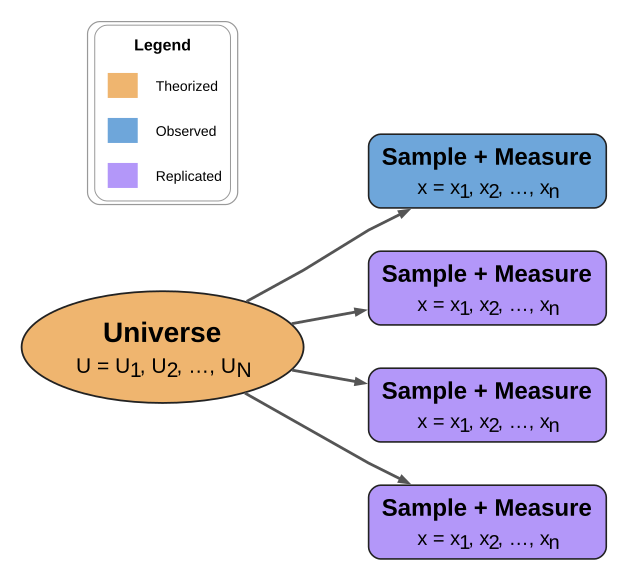

In [44]:
pic2

in label of node legend_3


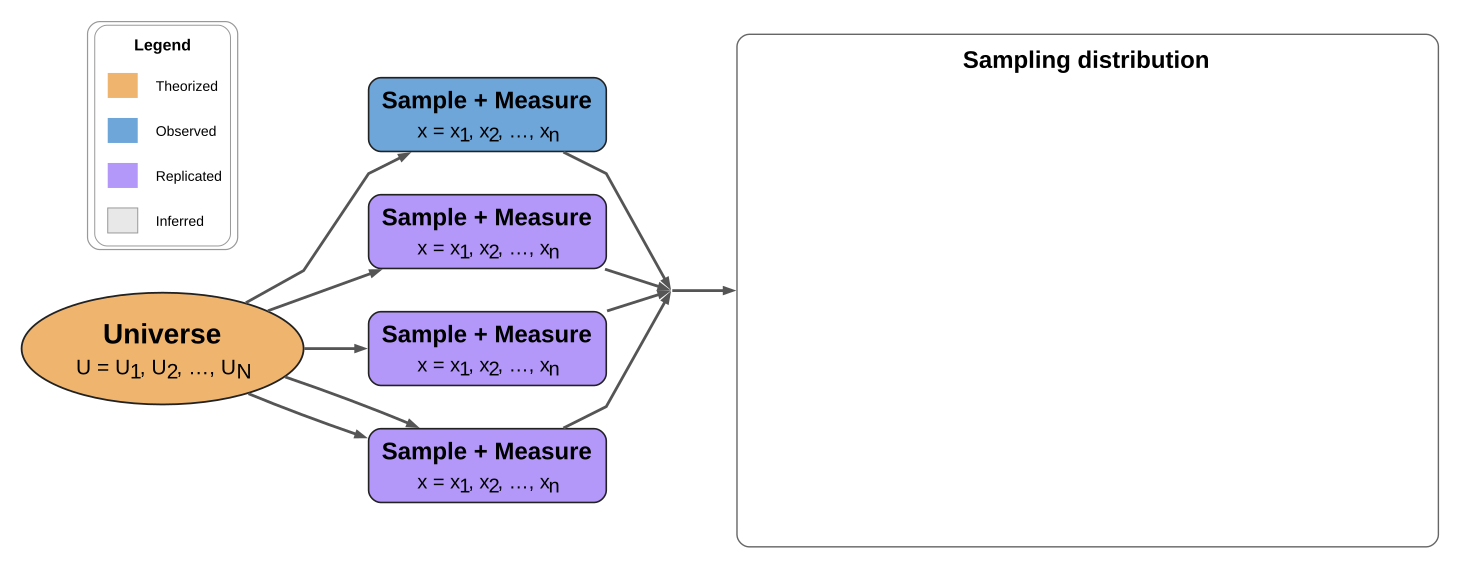

In [45]:
pic3

In [46]:
true_theta = theta_real

print(f"True θ: {true_theta:.4f}")

True θ: 0.8000


### Sample one real dataset

In [47]:
sample_size = len(data)          # same 30 observations as the Bayesian section above
real_data = int(np.sum(data))   # number of successes in those 30 trials

print(f"sample_size = {sample_size}, real_data = {real_data}, theta_hat = {real_data/sample_size:.3f}")

sample_size = 30, real_data = 23, theta_hat = 0.767


### Sampling distributions for a binomial estimator

C:\Users\User\AppData\Local\Temp\ipykernel_31560\677821649.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


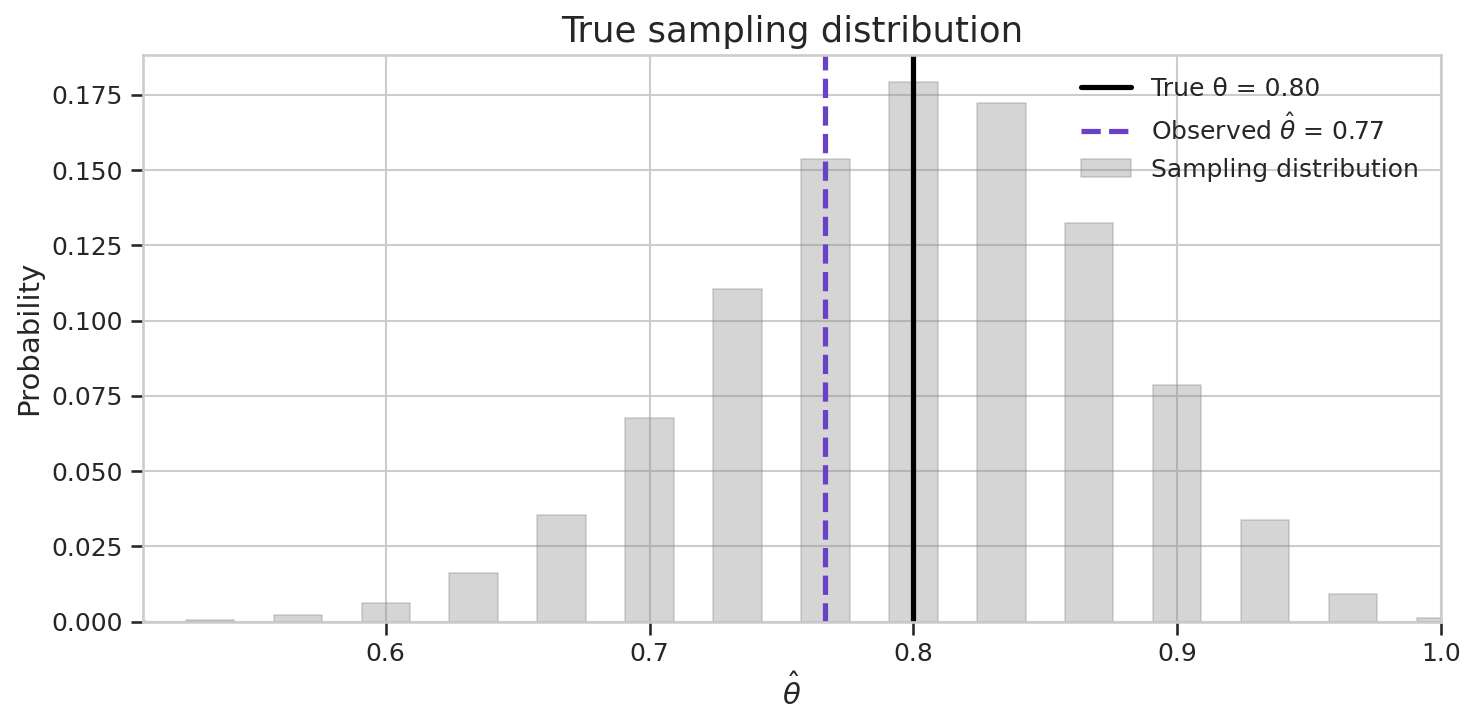

True θ: 0.80
Estimator: 0.77
Mean of sampling distribution: 0.7992
Std of sampling distribution: 0.0721


In [48]:
# Set estimator value

theta_estimator = real_data / sample_size

# Simulate datasets from the true data-generating distribution
simulated_data_values = np.asarray(
    pz.Binomial(n=sample_size, p=true_theta).rvs(1000, random_state=123)
).astype(int)
estimators = simulated_data_values / sample_size  # Convert counts to proportions
estimators = np.array(estimators)
weights = np.ones_like(estimators) / len(estimators)  # Equal weights for histogram

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Exact discrete PMF for the sampling distribution
x_vals = np.arange(0, sample_size + 1)
pmf = stats.binom.pmf(x_vals, sample_size, true_theta)
prop_vals = x_vals / sample_size

ax.bar(prop_vals, pmf, width=0.55 / sample_size, color="#888888", alpha=0.35, edgecolor="#888888", linewidth=0.8, label="Sampling distribution")

# Add vertical lines
ax.axvline(true_theta, color="black", linewidth=2.5, label=f"True θ = {true_theta:.2f}")
ax.axvline(
    theta_estimator,
    color="#6941c6",
    linestyle="--",
    linewidth=2.5,
    label=rf"Observed $\hat{{\theta}}$ = {theta_estimator:.2f}"
)

# Labels and formatting
ax.set_xlabel(r"$\hat{\theta}$", fontsize=14)
ax.set_ylabel("Probability", fontsize=14)
ax.set_title("True sampling distribution", fontsize=17)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)

# Zoom to ±4σ around the true value
sigma = np.sqrt(true_theta * (1 - true_theta) / sample_size)
ax.set_xlim(max(0, true_theta - 4 * sigma), min(1, true_theta + 4 * sigma))

plt.tight_layout()
plt.show()

print(f"True θ: {true_theta:.2f}")
print(f"Estimator: {theta_estimator:.2f}")
print(f"Mean of sampling distribution: {np.mean(estimators):.4f}")
print(f"Std of sampling distribution: {np.std(estimators):.4f}")

C:\Users\User\AppData\Local\Temp\ipykernel_31560\3055213328.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


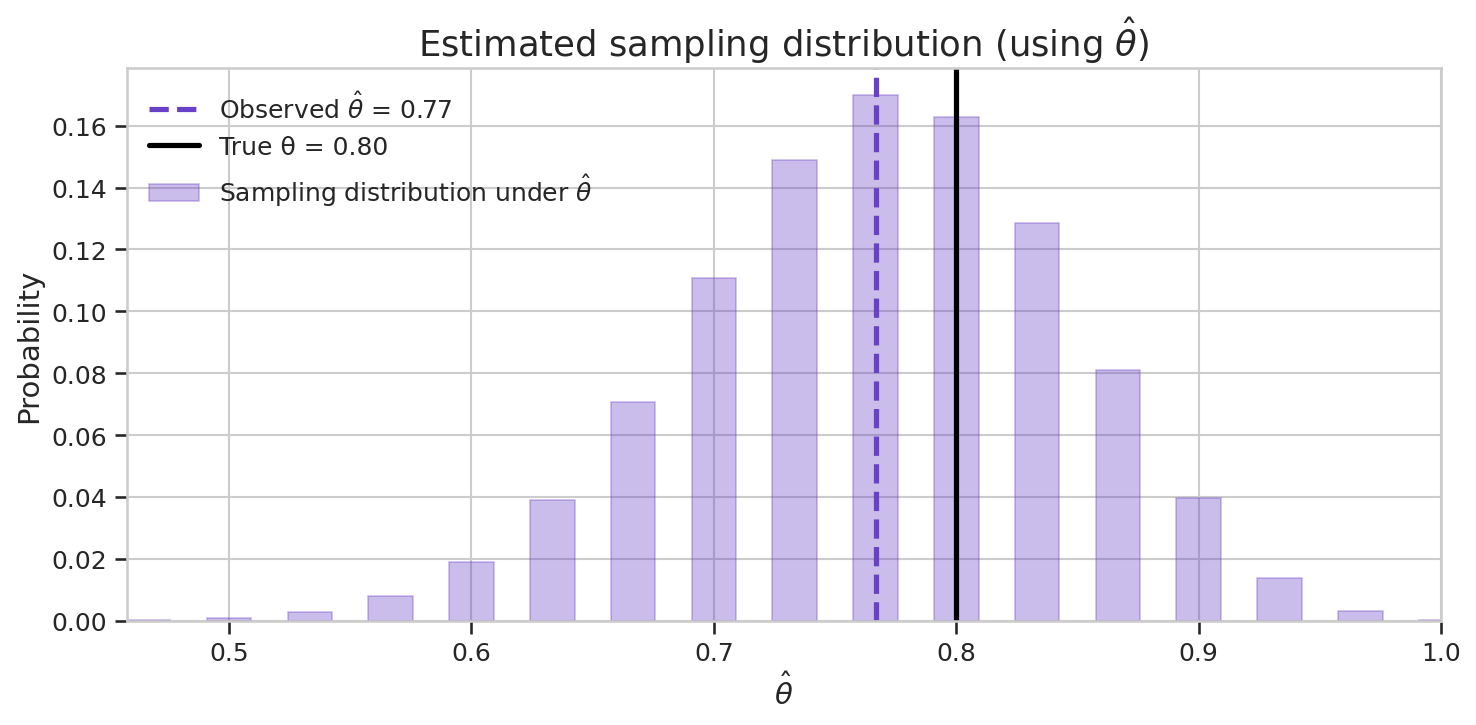

Estimator $\hat{\theta}$: 0.77
True θ: 0.80
Mean of exact distribution: 0.7667
Std of exact distribution: 0.0772


In [49]:
# Simulate sampling distribution using theta_estimator instead of true_theta
estimated_data_values = np.asarray(
    pz.Binomial(n=sample_size, p=theta_estimator).rvs(1000, random_state=123)
).astype(int)
estimated_estimators = estimated_data_values / sample_size  # Convert counts to proportions
estimated_estimators = np.array(estimated_estimators)
weights = np.ones_like(estimated_estimators) / len(estimated_estimators)  # Equal weights for histogram

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Exact PMF under theta_estimator
x_vals_est = np.arange(0, sample_size + 1)
pmf_est = stats.binom.pmf(x_vals_est, sample_size, theta_estimator)
prop_vals_est = x_vals_est / sample_size

ax.bar(prop_vals_est, pmf_est, width=0.55 / sample_size, color="#6941c6", alpha=0.35, edgecolor="#6941c6", linewidth=0.8, label=r'Sampling distribution under $\hat{\theta}$')

# Add vertical lines
ax.axvline(theta_estimator, color="#6941c6", linestyle="--", linewidth=2.5, label=rf'Observed $\hat{{\theta}}$ = {theta_estimator:.2f}')
ax.axvline(true_theta, color="black", linewidth=2.5, label=f'True θ = {true_theta:.2f}')

# Labels and formatting
ax.set_xlabel(r'$\hat{\theta}$', fontsize=14)
ax.set_ylabel('Probability', fontsize=14)
ax.set_title(r'Estimated sampling distribution (using $\hat{\theta}$)', fontsize=17)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=12)

# Zoom to ±4σ around theta_estimator
sigma_est = np.sqrt(theta_estimator * (1 - theta_estimator) / sample_size)
ax.set_xlim(max(0, theta_estimator - 4 * sigma_est), min(1, theta_estimator + 4 * sigma_est))

plt.tight_layout()
plt.show()

print(rf"Estimator $\hat{{\theta}}$: {theta_estimator:.2f}")
print(f"True θ: {true_theta:.2f}")
print(f"Mean of exact distribution: {np.sum(prop_vals_est * pmf_est):.4f}")
print(f"Std of exact distribution: {np.sqrt(np.sum((prop_vals_est - theta_estimator)**2 * pmf_est)):.4f}")

### Bounds and coverage logic
For the confidence-interval construction we define two statistics from the data:

- $	heta_L(y^*)$: the smallest parameter value for which data like ours are still plausible in the upper tail.
- $	heta_U(y^*)$: the largest parameter value for which data like ours are still plausible in the lower tail.

If those bounds have the advertised long-run coverage for every true $	heta$, then applying them to the observed dataset gives a valid confidence interval.

C:\Users\User\AppData\Local\Temp\ipykernel_31560\3992937360.py:66: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


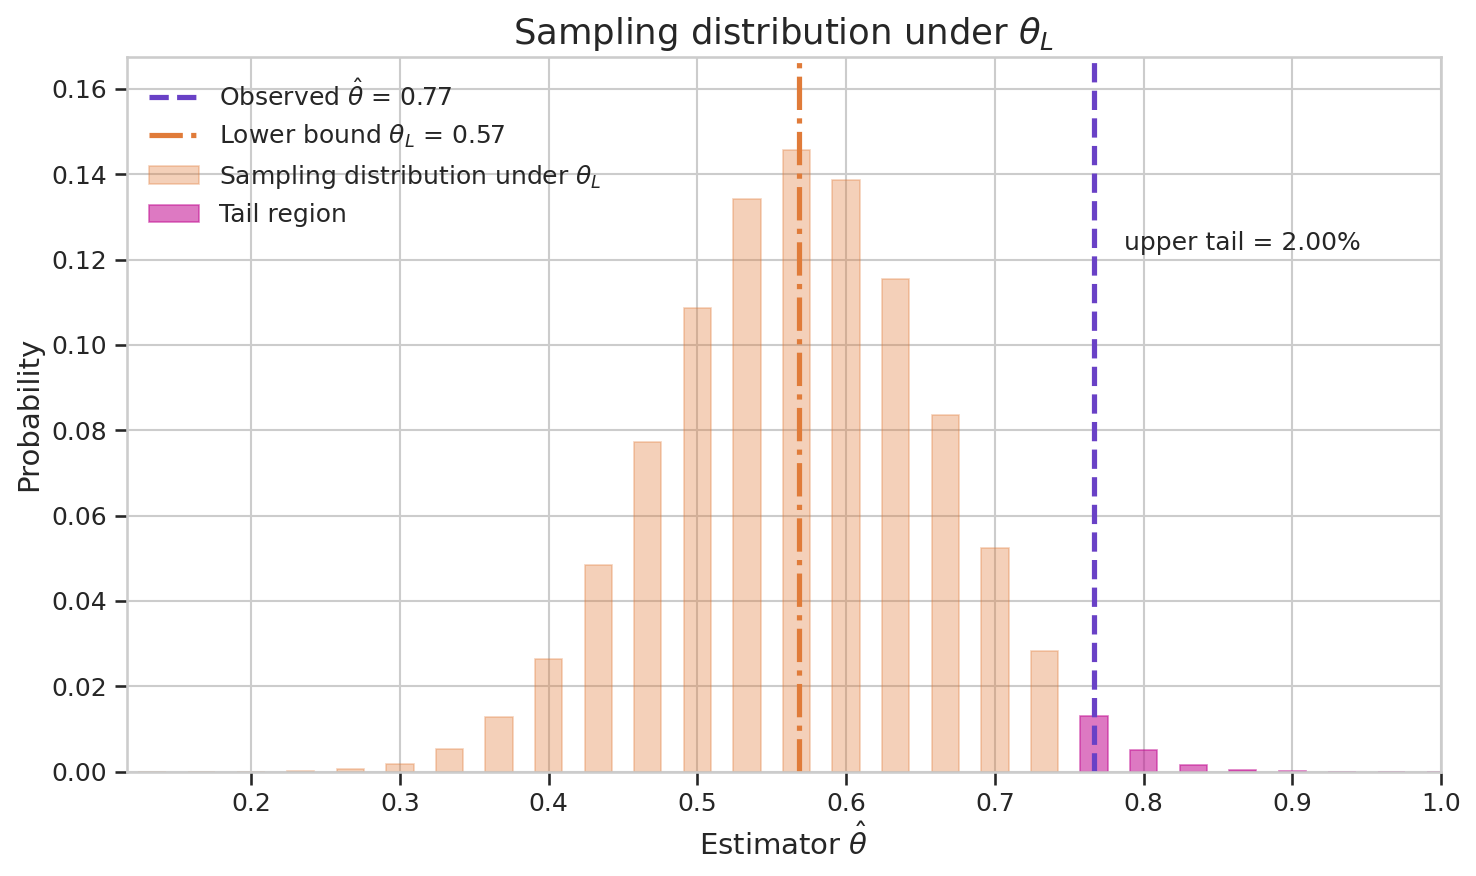

Observed x: 23
Observed estimator hat(theta): 0.77
Lower bound theta_L: 0.5685
Exact upper-tail probability P(hat(theta) >= observed | theta_L): 0.0200


In [50]:
# Exact lower confidence bound
ci_alpha = 0.04
tail_prob = ci_alpha / 2
theta_L = 0.0 if real_data == 0 else pz.Beta(real_data, sample_size - real_data + 1).ppf(tail_prob)

# Exact sampling distribution under theta_L
x_vals = np.arange(sample_size + 1)
estimator_vals = x_vals / sample_size
probs = stats.binom.pmf(x_vals, sample_size, theta_L)

# Tail probability at or above the observed estimator
tail_mask = estimator_vals >= theta_estimator
tail_exact = probs[tail_mask].sum()

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.55 / sample_size
ax.bar(
    estimator_vals[~tail_mask],
    probs[~tail_mask],
    width=bar_width,
    color='#e07b39',
    edgecolor='#e07b39',
    linewidth=0.8,
    alpha=0.35,
    label=rf"Sampling distribution under $\theta_L$"
)

ax.bar(
    estimator_vals[tail_mask],
    probs[tail_mask],
    width=bar_width,
    color='C3',
    edgecolor='C3',
    linewidth=0.8,
    alpha=0.55,
    label="Tail region"
)

# Vertical lines
ax.axvline(theta_estimator, color='#6941c6', linestyle='--', linewidth=2.5,
           label=rf'Observed $\hat{{\theta}}$ = {theta_estimator:.2f}')
ax.axvline(theta_L, color='#e07b39', linestyle='-.', linewidth=2.5,
           label=rf'Lower bound $\theta_L$ = {theta_L:.2f}')

# Annotation
y_text = probs.max() * 0.85
ax.text(
    theta_estimator + 0.02,
    y_text,
    rf'upper tail = {tail_exact:.2%}',
    fontsize=12,
    ha='left',
    va='center'
)
ax.set_xlabel(r'Estimator $\hat{\theta}$', fontsize=14)
ax.set_ylabel('Probability', fontsize=14)
ax.set_title(r'Sampling distribution under $\theta_L$', fontsize=17)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=12)
sigma_L = np.sqrt(theta_L * (1 - theta_L) / sample_size)
ax.set_xlim(max(0, theta_L - 5 * sigma_L), min(1, theta_L + 5 * sigma_L))
ax.set_ylim(0, probs.max() * 1.15)

plt.tight_layout()
plt.show()

print(f"Observed x: {real_data}")
print(f"Observed estimator hat(theta): {theta_estimator:.2f}")
print(f"Lower bound theta_L: {theta_L:.4f}")
print(f"Exact upper-tail probability P(hat(theta) >= observed | theta_L): {tail_exact:.4f}")

C:\Users\User\AppData\Local\Temp\ipykernel_31560\824622575.py:66: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


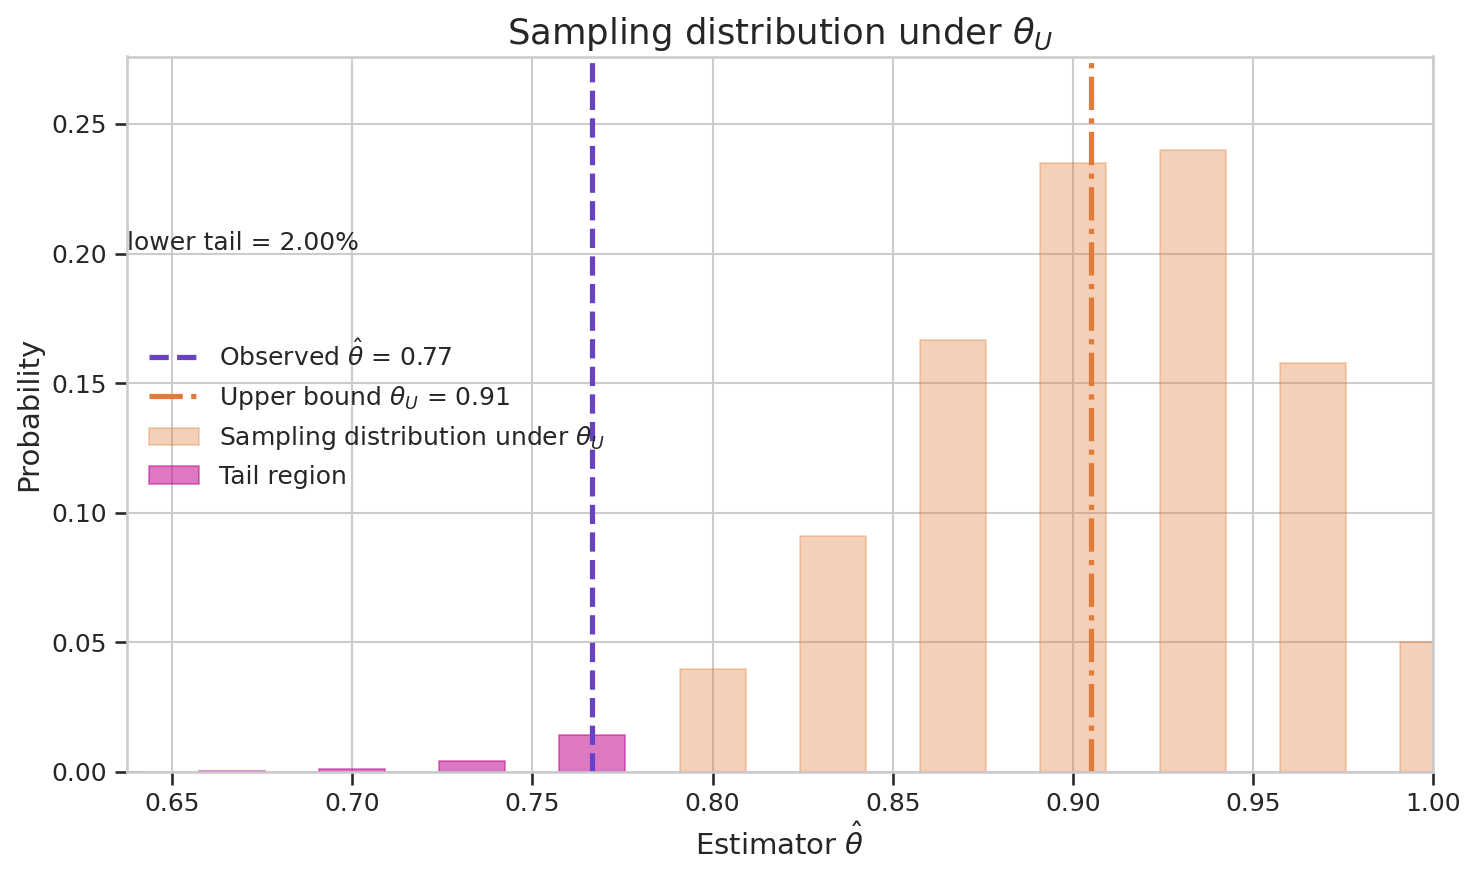

Observed x: 23
Observed estimator hat(theta): 0.77
Upper bound theta_U: 0.9050
Exact lower-tail probability P(hat(theta) <= observed | theta_U): 0.0200


In [51]:
# Exact upper confidence bound
theta_U = 1.0 if real_data == sample_size else pz.Beta(real_data + 1, sample_size - real_data).ppf(1 - tail_prob)

# Exact sampling distribution under theta_U
x_vals = np.arange(sample_size + 1)
estimator_vals = x_vals / sample_size
probs = stats.binom.pmf(x_vals, sample_size, theta_U)

# Lower-tail probability at or below the observed estimator
tail_mask = estimator_vals <= theta_estimator
tail_exact = probs[tail_mask].sum()

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.55 / sample_size
ax.bar(
    estimator_vals[~tail_mask],
    probs[~tail_mask],
    width=bar_width,
    color='#e07b39',
    edgecolor='#e07b39',
    linewidth=0.8,
    alpha=0.35,
    label=rf"Sampling distribution under $\theta_U$"
)

ax.bar(
    estimator_vals[tail_mask],
    probs[tail_mask],
    width=bar_width,
    color='C3',
    edgecolor='C3',
    linewidth=0.8,
    alpha=0.55,
    label="Tail region"
)

# Vertical lines
ax.axvline(theta_estimator, color='#6941c6', linestyle='--', linewidth=2.5,
           label=rf'Observed $\hat{{\theta}}$ = {theta_estimator:.2f}')
ax.axvline(theta_U, color='#e07b39', linestyle='-.', linewidth=2.5,
           label=rf'Upper bound $\theta_U$ = {theta_U:.2f}')

ax.set_xlabel(r'Estimator $\hat{\theta}$', fontsize=14)
ax.set_ylabel('Probability', fontsize=14)
ax.set_title(r'Sampling distribution under $\theta_U$', fontsize=17)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=12)
sigma_U = np.sqrt(theta_U * (1 - theta_U) / sample_size)
x_left = max(theta_U - 5 * sigma_U, theta_estimator - 2.5 * sigma_U)

# Annotation
y_text = probs.max() * 0.85
ax.text(
    x_left,
    y_text,
    rf'lower tail = {tail_exact:.2%}',
    fontsize=12,
    ha='left',
    va='center')

ax.set_xlim(max(0, theta_U - 5 * sigma_U), min(1, theta_U + 5 * sigma_U))
ax.set_ylim(0, probs.max() * 1.15)

plt.tight_layout()
plt.show()

print(f"Observed x: {real_data}")
print(f"Observed estimator hat(theta): {theta_estimator:.2f}")
print(f"Upper bound theta_U: {theta_U:.4f}")
print(f"Exact lower-tail probability P(hat(theta) <= observed | theta_U): {tail_exact:.4f}")

C:\Users\User\AppData\Local\Temp\ipykernel_31560\2243835825.py:66: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


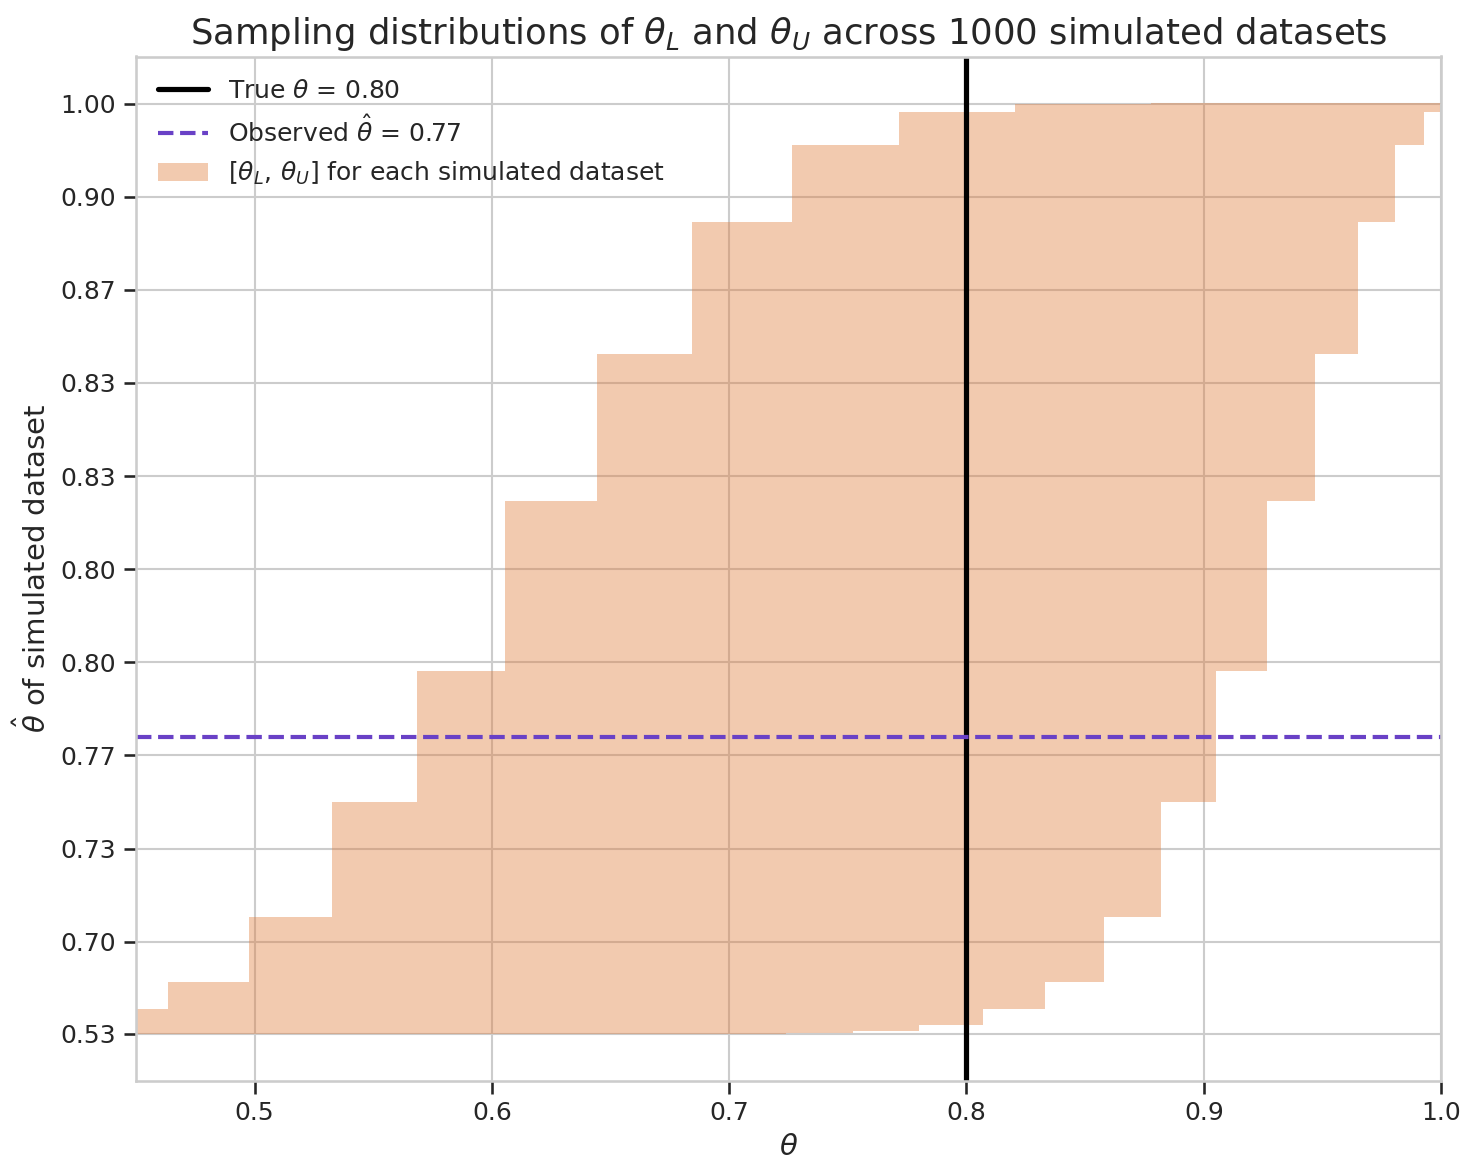

Mean theta_L: 0.6098
Mean theta_U: 0.9231
Mean interval width: 0.3133
Observed dataset rank: 319 / 1000  (theta_hat = 0.77)


In [52]:
# Sampling distributions of theta_L and theta_U:
# simulate 1000 datasets under true_theta and compute the bounds for each
ci_alpha = 0.04
tail_prob = ci_alpha / 2
num_samples = 1000
simulated_counts = pz.Binomial(n=sample_size, p=true_theta).rvs(num_samples, random_state=42)

theta_hat_samples = simulated_counts / sample_size
theta_L_samples = np.zeros(num_samples)
theta_U_samples = np.zeros(num_samples)

for i, x in enumerate(simulated_counts):
    x = int(x)
    theta_L_samples[i] = 0.0 if x == 0 else pz.Beta(x, sample_size - x + 1).ppf(tail_prob)
    theta_U_samples[i] = 1.0 if x == sample_size else pz.Beta(x + 1, sample_size - x).ppf(1 - tail_prob)

# Sort by estimated theta so the plot reads as a smooth caterpillar
sort_idx = np.argsort(theta_hat_samples)
theta_hat_sorted = theta_hat_samples[sort_idx]
theta_L_sorted = theta_L_samples[sort_idx]
theta_U_sorted = theta_U_samples[sort_idx]

# Find y-position of our observed dataset (midpoint of its group in the sorted array)
obs_lo = np.searchsorted(theta_hat_sorted, theta_estimator, side='left')
obs_hi = np.searchsorted(theta_hat_sorted, theta_estimator, side='right')
obs_rank = (obs_lo + obs_hi - 1) / 2

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
y = np.arange(num_samples)

ax.barh(
    y,
    theta_U_sorted - theta_L_sorted,
    left=theta_L_sorted,
    height=1.0,
    color='#e07b39',
    alpha=0.4,
    linewidth=0,
    label=r'$[\theta_L,\, \theta_U]$ for each simulated dataset'
)

ax.axvline(true_theta, color='black', linewidth=2.5,
           label=fr'True $\theta$ = {true_theta:.2f}')
ax.axhline(obs_rank, color='#6941c6', linestyle='--', linewidth=2.0,
           label=rf'Observed $\hat{{\theta}}$ = {theta_estimator:.2f}')

# Y-ticks: evenly spaced ranks labelled with the theta_hat at that rank
tick_positions = np.linspace(0, num_samples - 1, 11, dtype=int)
tick_labels = [f'{theta_hat_sorted[p]:.2f}' for p in tick_positions]
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels, fontsize=11)

ax.set_xlabel(r'$\theta$', fontsize=14)
ax.set_ylabel(r'$\hat{\theta}$ of simulated dataset', fontsize=14)
ax.set_title(
    fr'Sampling distributions of $\theta_L$ and $\theta_U$ across {num_samples} simulated datasets',
    fontsize=17
)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=12, loc='upper left')
ax.set_xlim(
    max(0, true_theta - 0.35),
    min(1, true_theta + 0.35)
)
plt.tight_layout()
plt.show()

print(f'Mean theta_L: {theta_L_samples.mean():.4f}')
print(f'Mean theta_U: {theta_U_samples.mean():.4f}')
print(f'Mean interval width: {(theta_U_samples - theta_L_samples).mean():.4f}')
print(f'Observed dataset rank: {int(obs_rank)} / {num_samples}  (theta_hat = {theta_estimator:.2f})')

C:\Users\User\AppData\Local\Temp\ipykernel_31560\1774269493.py:68: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


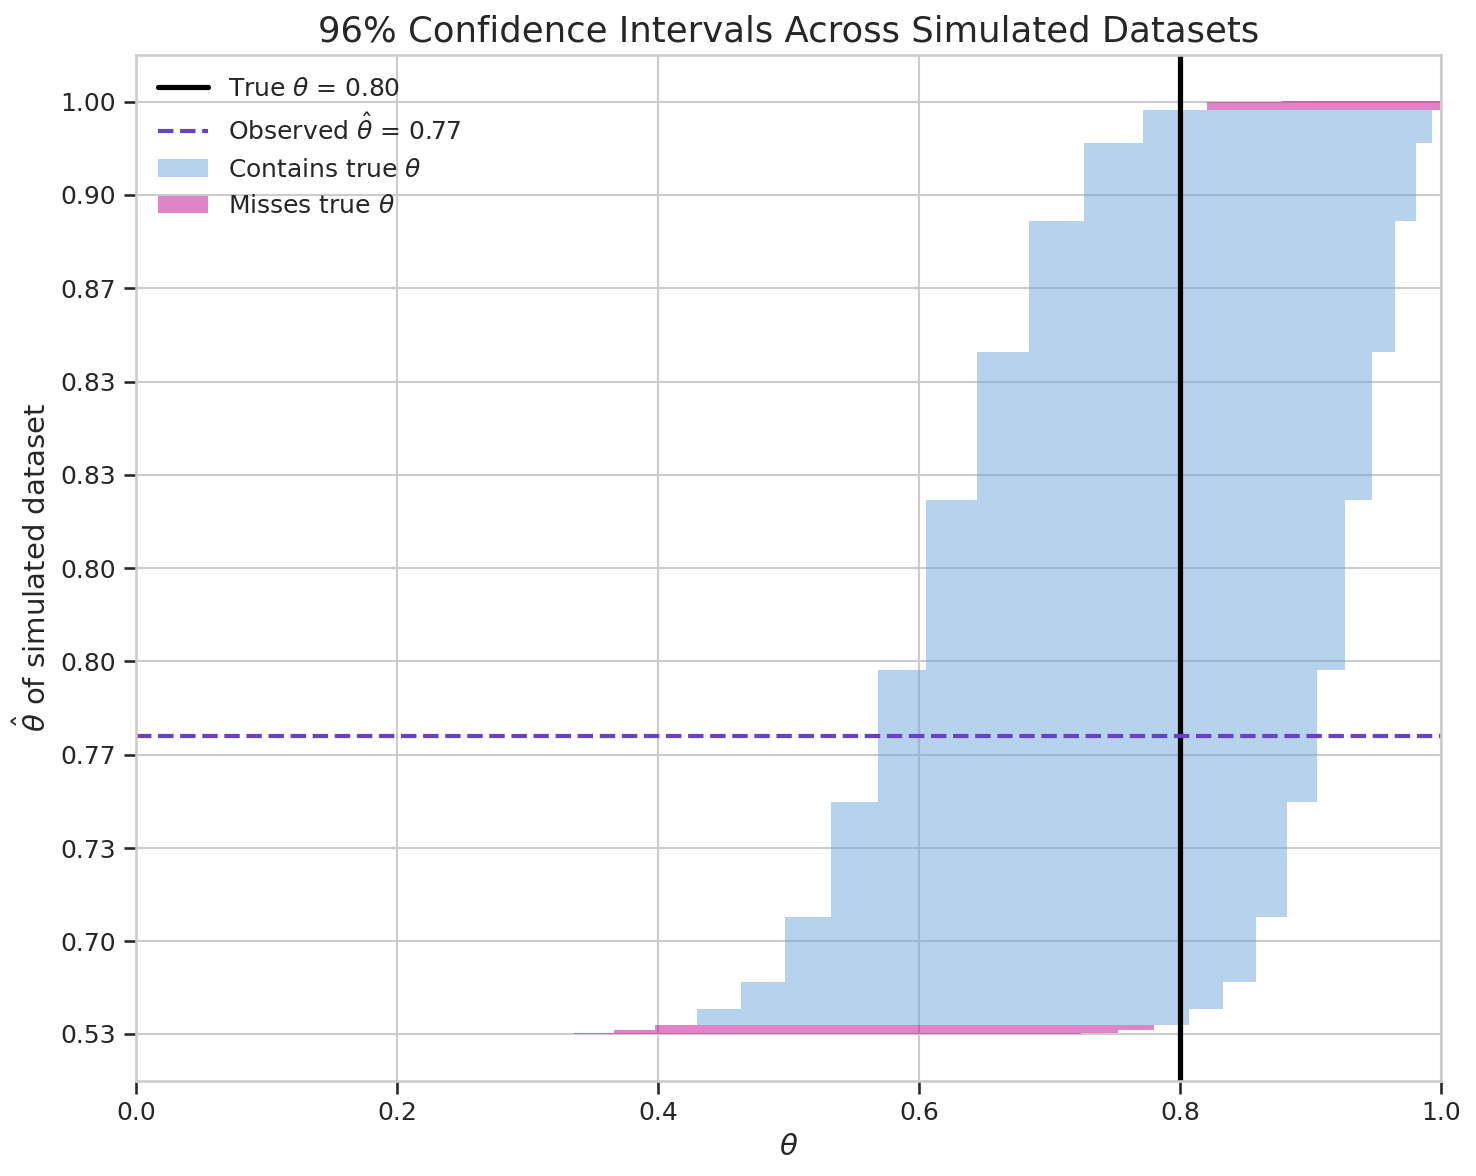

Coverage: 98.0% of intervals contain true theta = 0.80
Nominal level: 96%


In [53]:
# Coverage plot: 96% CIs across simulated datasets (styled like the HDI coverage plot)
ci_alpha = 0.04
tail_prob = ci_alpha / 2
num_samples = 1000
simulated_counts = pz.Binomial(n=sample_size, p=true_theta).rvs(num_samples, random_state=42)

theta_hat_samples = simulated_counts / sample_size
theta_L_samples = np.zeros(num_samples)
theta_U_samples = np.zeros(num_samples)

for i, x in enumerate(simulated_counts):
    x = int(x)
    theta_L_samples[i] = 0.0 if x == 0 else pz.Beta(x, sample_size - x + 1).ppf(tail_prob)
    theta_U_samples[i] = 1.0 if x == sample_size else pz.Beta(x + 1, sample_size - x).ppf(1 - tail_prob)

# Coverage
covers = (theta_L_samples <= true_theta) & (true_theta <= theta_U_samples)
coverage = covers.mean() * 100

# Sort by estimated theta
sort_idx = np.argsort(theta_hat_samples)
theta_hat_sorted = theta_hat_samples[sort_idx]
theta_L_sorted = theta_L_samples[sort_idx]
theta_U_sorted = theta_U_samples[sort_idx]
covers_sorted = covers[sort_idx]

# Rank of our observed dataset
obs_lo = np.searchsorted(theta_hat_sorted, theta_estimator, side='left')
obs_hi = np.searchsorted(theta_hat_sorted, theta_estimator, side='right')
obs_rank_ci = (obs_lo + obs_hi - 1) / 2

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
y = np.arange(num_samples)

for covers_val, color in [(True, '#6ea6da'), (False, 'C3')]:
    mask = covers_sorted == covers_val
    label = r'Contains true $\theta$' if covers_val else r'Misses true $\theta$'
    ax.barh(
        y[mask],
        theta_U_sorted[mask] - theta_L_sorted[mask],
        left=theta_L_sorted[mask],
        height=1.0,
        color=color,
        alpha=0.5,
        linewidth=0,
        label=label
    )

ax.axvline(true_theta, color='black', linewidth=2.5,
           label=fr'True $\theta$ = {true_theta:.2f}')
ax.axhline(obs_rank_ci, color='#6941c6', linestyle='--', linewidth=2.0,
           label=rf'Observed $\hat{{\theta}}$ = {theta_estimator:.2f}')

# Y-ticks labelled with theta_hat at that rank
tick_positions = np.linspace(0, num_samples - 1, 11, dtype=int)
tick_labels = [f'{theta_hat_sorted[p]:.2f}' for p in tick_positions]
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels, fontsize=11)

ax.set_xlabel(r'$\theta$', fontsize=14)
ax.set_ylabel(r'$\hat{\theta}$ of simulated dataset', fontsize=14)
ax.set_title(fr'{int((1-ci_alpha)*100)}% Confidence Intervals Across Simulated Datasets',
             fontsize=17)
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=12, loc='upper left')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

print(f'Coverage: {coverage:.1f}% of intervals contain true theta = {true_theta:.2f}')
print(f'Nominal level: {int((1-ci_alpha)*100)}%')

In [54]:
import pytensor.tensor as pt

# Wilson score interval parameters for a 96% CI (2% in each tail)
ci_alpha = 0.04
tail_prob = ci_alpha / 2
z = stats.norm.ppf(1 - tail_prob)
z2 = z**2
n = sample_size

def symbolic_LH(d):
    term1 = (d + z2 / 2) / (n + z2)
    term2 = (z / (n + z2)) * pt.sqrt((d * (n - d)) / n + z2 / 4)
    L = term1 - term2
    H = term1 + term2
    return L, H

# Numeric version for the observed data (using NumPy)
def numeric_LH(d):
    d = np.asarray(d, dtype=float)
    term1 = (d + z2 / 2) / (n + z2)
    term2 = (z / (n + z2)) * np.sqrt(np.clip(d * (n - d) / n + z2 / 4, 0, None))
    L = term1 - term2
    H = term1 + term2
    return L, H

with pm.Model() as test_confidence_interval_model:
    simulated_data = pm.Binomial("simulated_data", n=n, p=true_theta)

    # Confidence bounds
    L, H = symbolic_LH(simulated_data)

    # Coverage indicator
    covered = pm.Deterministic("covered", (L <= true_theta) & (true_theta <= H))

    # Sample from the model
    prior_pred = pm.sample_prior_predictive(samples=5000, random_seed=123)

coverage = prior_pred.prior["covered"].mean()
print("Coverage:", coverage)

Sampling: [simulated_data]


Coverage: <xarray.DataArray 'covered' ()> Size: 8B
array(0.964)


### Calculate the confidence interval for the observed data

In [55]:
CI = numeric_LH(real_data)
print(CI)

(np.float64(0.5817060336705375), np.float64(0.8858857006720307))


### Coverage across different true $\theta$ values

In [56]:
coords = dict(
    true_theta_dim=np.arange(1000),
    sim_data_dim=np.arange(50000)
)

with pm.Model(coords=coords) as coverage_model:
    true_theta = pm.Beta("true_theta", alpha=1.0, beta=1.0, dims="true_theta_dim")
    simulated_data = pm.Binomial("simulated_data", n=n, p=true_theta[:, None], dims=("true_theta_dim", "sim_data_dim"))
    L, H = symbolic_LH(simulated_data)
    covered = pm.Deterministic("covered", (L <= true_theta[:, None]) & (true_theta[:, None] <= H), dims=("true_theta_dim", "sim_data_dim"))
    coverage = pm.Deterministic("coverage", covered.mean(axis=1), dims="true_theta_dim")
    prior_pred = pm.sample_prior_predictive(samples=1, random_seed=123)


Sampling: [simulated_data, true_theta]


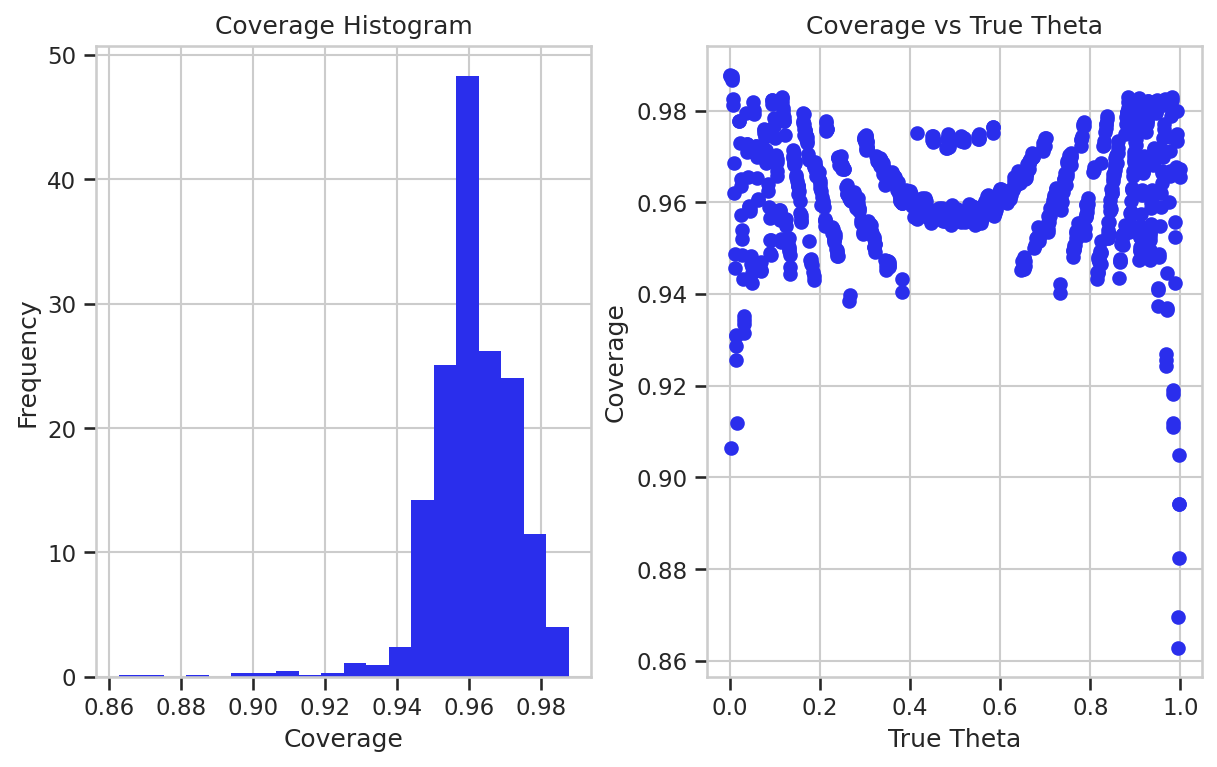

In [57]:
true_theta_vals = prior_pred.prior["true_theta"][0].values
coverage_vals   = prior_pred.prior["coverage"][0].values

fig, ax = plt.subplots(1, 2, figsize=(8, 5)) 

ax[0].hist(coverage_vals.T, bins=20, density=True)
ax[0].set_title("Coverage Histogram")
ax[0].set_xlabel("Coverage")
ax[0].set_ylabel("Frequency")

ax[1].scatter(true_theta_vals, coverage_vals)
ax[1].set_title("Coverage vs True Theta")
ax[1].set_xlabel("True Theta")
ax[1].set_ylabel("Coverage")
plt.show()

### Functions to calculate confidence intervals
There is more than one way to build a confidence interval, and different methods rely on different assumptions. The slides mention common choices such as normal, Agresti-Coull, beta, and Wilson intervals.

```python
from statsmodels.stats.proportion import proportion_confint

proportion_confint(count=real_data, nobs=sample_size, alpha=0.04, method="wilson")
```

Common methods discussed in the slides include `normal`, `agresti_coull`, `beta`, and `wilson`.

### Common misinterpretations of confidence intervals

- “There is a 95% chance the true parameter is in this interval” is a Bayesian statement, not a frequentist CI statement.
- A confidence interval describes the long-run behavior of a procedure over repeated datasets.
- It does not directly assign probability to the fixed parameter for the one dataset we observed.

<a id="section-311"></a>
## 3.11 Next time: MCMC
Posterior distributions are often hard to sample from directly, so the next lecture asks how sampling algorithms actually work. We will move from using `pm.sample()` as a black box to understanding the logic behind MCMC.